# Loading, cleaning and displaying gas exchange data

This is an example of how to load, clean and display gas exchange data from a Licor-6800 file. \
More information about the symbols can be found here: \
https://www.licor.com/support/LI-6800/topics/symbols.html#GasEx

Load some libraries for data processing and plotting.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Set the style for prettier plots
plt.style.use('seaborn-v0_8-whitegrid')

This function reads the data while accounting for the data structure.

In [2]:
def load_gas_exchange_file(filepath):
    """
    Parses the custom text file, skips the header, deduplicates column names, 
    and extracts the data.
    """
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
        
    data_idx = -1
    for i, line in enumerate(lines):
        if line.strip() == '[Data]':
            data_idx = i
            break
            
    if data_idx == -1:
        print(f"Skipping {filepath} - No '[Data]' tag found.")
        return None
        
    # Extract raw column names
    raw_col_names = lines[data_idx + 2].strip('\n').split('\t')
    
    # Deduplicate column names (e.g., turn duplicate "TIME" into "TIME_1")
    col_names = []
    seen_names = {}
    
    for name in raw_col_names:
        # Handle trailing tabs which create empty strings
        if not name.strip():
            name = "Unnamed"
            
        if name in seen_names:
            seen_names[name] += 1
            col_names.append(f"{name}_{seen_names[name]}")
        else:
            seen_names[name] = 0
            col_names.append(name)
    
    # Read the data into a pandas DataFrame
    try:
        df = pd.read_csv(
            filepath, 
            sep='\t', 
            skiprows=data_idx + 4, 
            names=col_names, 
            index_col=False,
            engine='python' 
        )
        # Drop empty columns
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
        return df
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

Here you can change the directory you want to load.
It loads all the data files of the directory into a dictionary. \
The data is cleaned by removing outliers or other problems. \
During self-calibration (detected by LeakPct > 1) the instrument continue to record but the data is not valid. \
Some cleaning steps are necessary to remove other types of invalid points (gsw values that are outside realistic values).

In [3]:
# Set your directory path here. Use '.' for the current directory.
DIRECTORY = 'Data/Training' 

# Define your quality control thresholds
leak_threshold = 1.0
gs_min = 0.0
gs_max = 0.6

data_dict = {}

# Iterate over files in the directory
for filename in os.listdir(DIRECTORY):
    filepath = os.path.join(DIRECTORY, filename)
    
    # Check if it's a file and has no extension
    if os.path.isfile(filepath) and '.' not in filename:
        df = load_gas_exchange_file(filepath)
        
        if df is not None and not df.empty:
            initial_len = len(df)
            
            # --- CLEANING STEP 1: LEAK ---
            if 'LeakPct' in df.columns:
                df['Leak'] = pd.to_numeric(df['LeakPct'], errors='coerce')
                df = df[df['Leak'] <= leak_threshold]
            else:
                print(f"Warning: 'LeakPct' column not found in {filename}.")
                
            # --- CLEANING STEP 2: STOMATAL CONDUCTANCE (gsw) ---
            gs_col = 'gsw' if 'gsw' in df.columns else ('gs' if 'gs' in df.columns else None)
            if gs_col:
                df[gs_col] = pd.to_numeric(df[gs_col], errors='coerce')
                df = df[(df[gs_col] >= gs_min) & (df[gs_col] <= gs_max)]
            else:
                print(f"Warning: Neither 'gsw' nor 'gs' column found in {filename}.")
            
            dropped_rows = initial_len - len(df)
            
            # Only add to dictionary if there's still data left after cleaning
            if not df.empty:
                data_dict[filename] = df
                print(f"Loaded & Cleaned: {filename} ({len(df)} rows kept, {dropped_rows} dropped).")
            else:
                print(f"Skipping {filename}: All rows were filtered out during cleaning.")

if not data_dict:
    print("No valid files found, or all data was filtered out.")

Loaded & Cleaned: 2023-08-25-1038_logdata_silvere2_flash (5642 rows kept, 46 dropped).


Loaded & Cleaned: 2023-08-30-1101_logdata_silvere2_flash (5638 rows kept, 33 dropped).


Loaded & Cleaned: 2023-09-06-1204_logdata_silvere2_flash (5655 rows kept, 30 dropped).


Loaded & Cleaned: 2023-09-22-1242_logdata_silvere2_flash (5598 rows kept, 44 dropped).


Loaded & Cleaned: 2023-10-24-1257_logdata_silvere2_flash (5602 rows kept, 67 dropped).


Loaded & Cleaned: 2023-10-24-1300_logdata2_silvere2_flash (5538 rows kept, 30 dropped).


Display the cleaned data. You can visually inspect the data and start thinking about a model :-D

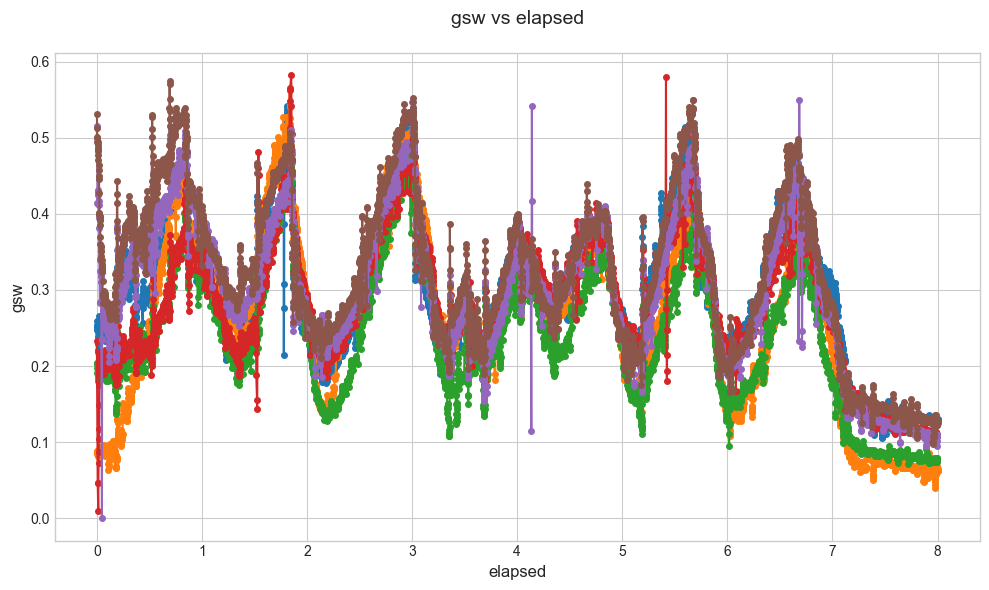

In [4]:
# Define which columns to plot
x_col = 'elapsed'
y_col = 'gsw'

plt.figure(figsize=(10, 6))

for filename, df in data_dict.items():
    if x_col in df.columns and y_col in df.columns:
        
        # Convert plotting columns to numeric (just in case)
        x_data = pd.to_numeric(df[x_col], errors='coerce')
        y_data = pd.to_numeric(df[y_col], errors='coerce')
        
        # Plot the pre-cleaned data
        plt.plot(x_data/3600, y_data, marker='o', linestyle='-', markersize=4, label=filename)
    else:
        print(f"Warning: Columns '{x_col}' or '{y_col}' not found in {filename}.")

# We can still reference the thresholds in the title since they were defined in Cell 3
plt.title(f'{y_col} vs {x_col}\n', fontsize=14)
plt.xlabel(f'{x_col}', fontsize=12)
plt.ylabel(f'{y_col}', fontsize=12)
#plt.legend(title="Files", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Model-Based Stomatal Conductance Prototype

This section adds a model-based prototype for predicting stomatal conductance (`gsw`) from LI-6800 environmental variables.

The earlier notebook cells load, clean, and explore the data. Those cells are intentionally left unchanged. The modelling code below creates separate modelling copies of the Training and Validation data so that the original `data_dict` is not overwritten.

The target variable is `gsw`. The candidate predictors are environmental and chamber variables:

- `Qin`: incoming light intensity
- `Ca`: ambient CO2 concentration
- `VPDleaf`: leaf vapour pressure deficit
- `Tleaf`: leaf temperature
- `Tair`: air temperature
- `RHcham`: chamber relative humidity

Measured `A` is **not** used as an input to predict `gsw`. It is only kept for evaluation, because using measured assimilation directly would leak information from the plant response into the stomatal conductance model. Instead, assimilation is simulated as an intermediate variable using a simple light-response function.

## Modelling Rationale

A model-based approach was selected because stomatal conductance is not just a statistical response to one variable. It is biologically linked to light, CO2, vapour pressure deficit, and photosynthetic demand.

`Qin`, `Ca`, and `VPDleaf` are especially meaningful:

- Light (`Qin`) drives photosynthesis and stomatal opening.
- Ambient CO2 (`Ca`) affects the CO2 gradient and stomatal regulation.
- Vapour pressure deficit (`VPDleaf`) represents atmospheric water demand; stomata often close when VPD increases.

The Leuning-type model was selected as the main literature-based prototype because it links stomatal conductance to assimilation, CO2 concentration, and VPD. In this notebook, assimilation is simulated rather than taken from measured `A`.

## Models Implemented

**Model 0: simple empirical baseline**

Uses only light and VPD:

```text
gsw_pred = g0 + a * Qin / (Kq + Qin) * 1 / (1 + VPDleaf / D0)
```

**Model 1: Leuning 1995 model with simulated photosynthesis**

First simulates assimilation:

```text
A_model = (Amax * Qin) / (K + Qin) - Rd
```

Then predicts stomatal conductance:

```text
gsw_pred = g0 + gL * A_model / ((1 + VPDleaf / D0) * (Ca - Gamma))
```

**Model 2: dynamic Leuning model with stomatal time lag**

First calculates the Leuning target, then applies a lag:

```text
gsw_dynamic[t] = gsw_dynamic[t-1] + k_lag * (gsw_target[t] - gsw_dynamic[t-1])
```

Training data are used for parameter fitting only. Validation data are kept separate and used only for final evaluation.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from IPython.display import display

MODEL_COLUMNS = ["gsw", "Qin", "Ca", "VPDleaf", "Tleaf", "Tair", "RHcham", "A", "elapsed"]

# Model-specific outlier filters.
# These filters are applied only to modelling copies (train_df / validation_df),
# not to the original data_dict created in the earlier notebook cells.
OUTLIER_FILTERS = {
    "gsw": (0, 0.6),
    "Qin": (0, 2000),
    "Ca": (300, 500),
    "VPDleaf": (0, 2),
    "Tleaf": (15, 35),
    "Tair": (15, 35),
    "RHcham": (30, 90),
}


def remove_gsw_spikes(df, gsw_col="gsw", window=21, threshold=0.08):
    """Remove isolated gsw spikes using a centered rolling median filter."""
    if gsw_col not in df.columns:
        return df.copy()

    filtered_df = df.copy()
    gsw = pd.to_numeric(filtered_df[gsw_col], errors="coerce")
    rolling_median = gsw.rolling(window=window, center=True, min_periods=5).median()
    deviation = (gsw - rolling_median).abs()
    keep = rolling_median.isna() | (deviation <= threshold)
    return filtered_df[keep].copy()


def prepare_model_data(df):
    """Create a modelling copy with numeric variables and modelling-specific outlier filters."""
    model_df = df.copy()
    initial_rows = len(model_df)

    for col in MODEL_COLUMNS:
        if col in model_df.columns:
            model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    # Required model variables. Measured A is kept for evaluation only and is not
    # used as an input for predicting gsw.
    required = ["gsw", "Qin", "Ca", "VPDleaf", "Tleaf", "Tair", "RHcham", "A"]
    model_df = model_df.dropna(subset=required)
    after_missing = len(model_df)

    for col, (lower, upper) in OUTLIER_FILTERS.items():
        if col in model_df.columns:
            model_df = model_df[model_df[col].between(lower, upper)].copy()

    # A is not used as a predictor. This optional filter removes clearly
    # unrealistic assimilation values so the A_model vs measured A diagnostic
    # plot is not dominated by instrument artefacts.
    if "A" in model_df.columns:
        model_df = model_df[model_df["A"].between(-10, 50)].copy()

    print(
        "Model data cleaning: "
        f"{initial_rows:,} rows -> {after_missing:,} after missing-value removal -> "
        f"{len(model_df):,} after outlier filters"
    )

    return model_df.reset_index(drop=True)


def combine_data_dict(data_dict):
    """Combine a dictionary of dataframes and preserve the source file name."""
    frames = []
    for filename, df in data_dict.items():
        temp = df.copy()
        temp["_file"] = filename
        frames.append(temp)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def load_clean_folder_for_model(directory):
    """Load files from one folder using the existing parser, then apply the same early QC rules."""
    model_data_dict = {}

    for filename in sorted(os.listdir(directory)):
        filepath = os.path.join(directory, filename)
        if os.path.isfile(filepath) and "." not in filename:
            df = load_gas_exchange_file(filepath)

            if df is None or df.empty:
                continue

            df = df.copy()

            if "LeakPct" in df.columns:
                df["Leak"] = pd.to_numeric(df["LeakPct"], errors="coerce")
                df = df[df["Leak"] <= leak_threshold]

            if "gsw" in df.columns:
                df["gsw"] = pd.to_numeric(df["gsw"], errors="coerce")
                df = df[(df["gsw"] >= gs_min) & (df["gsw"] <= gs_max)]
                df = remove_gsw_spikes(df, gsw_col="gsw", window=21, threshold=0.08)

            if not df.empty:
                model_data_dict[filename] = df

    return model_data_dict


training_model_dict = load_clean_folder_for_model("Data/Training")
validation_model_dict = load_clean_folder_for_model("Data/Validation")

train_df_raw = combine_data_dict(training_model_dict)
validation_df_raw = combine_data_dict(validation_model_dict)

train_df = prepare_model_data(train_df_raw)
validation_df = prepare_model_data(validation_df_raw)

print(f"Training rows for modelling: {len(train_df):,}")
print(f"Validation rows for modelling: {len(validation_df):,}")
print(f"Training files: {train_df['_file'].nunique() if '_file' in train_df else 0}")
print(f"Validation files: {validation_df['_file'].nunique() if '_file' in validation_df else 0}")

display(train_df[["gsw", "Qin", "Ca", "VPDleaf", "Tleaf", "Tair", "RHcham", "A"]].describe().T)

Model data cleaning: 33,568 rows -> 33,568 after missing-value removal -> 33,563 after outlier filters


Model data cleaning: 27,646 rows -> 27,646 after missing-value removal -> 27,645 after outlier filters
Training rows for modelling: 33,563
Validation rows for modelling: 27,645
Training files: 6
Validation files: 5


,count,mean,std,min,25%,50%,75%,max
gsw,33563.0,0.285429,0.101375,0.039548,0.220645,0.285077,0.356156,0.562059
Qin,33563.0,593.588933,580.231861,0.019997,50.059700,349.245000,1199.910000,1750.260000
Ca,33563.0,395.131391,3.786077,388.700000,391.451996,395.178996,398.991000,400.888000
VPDleaf,33563.0,0.890232,0.068804,0.706930,0.839929,0.881128,0.933003,1.167149
Tleaf,33563.0,22.423678,0.430717,21.109700,22.111700,22.379200,22.697250,24.100000
Tair,33563.0,22.995265,0.043324,22.637200,22.982550,22.993300,23.007400,23.276800
RHcham,33563.0,65.040532,0.202692,56.776426,64.928110,65.035236,65.151447,67.430710
A,33563.0,11.203951,9.246224,-3.846238,1.629797,11.109711,20.215536,26.742023


## Data Combination Diagnostic

The Training files are combined row by row with `pd.concat(frames, ignore_index=True)`. They are not averaged and they are not merged by matching `elapsed` time. Before concatenation, `combine_data_dict()` adds a `_file` column, so each row keeps the name of the original source file.

For Model 2 and Model 3, the dynamic stomatal simulation is reset for each original file using `df.groupby("_file", sort=False)`. This means the fitted parameters use all Training rows, but the dynamic state is not carried from the end of one file into the start of the next file.

Some time-series plots show one continuous line because the plotting helper first selects one representative file and then plots `elapsed / 3600` within that file. If the concatenated dataframe is plotted directly against row index, it can also look like one long continuous line, but that is only a plotting/index choice; the dynamic models still preserve file identity through `_file`.


## Model Functions

The functions below implement the three requested models.

Parameter meanings:

| Parameter | Meaning |
|---|---|
| `g0` | residual/minimum stomatal conductance |
| `a` | empirical maximum response scale for Model 0 |
| `Kq` | half-saturation constant for light in Model 0 |
| `Amax` | maximum simulated assimilation rate |
| `K` | half-saturation constant for the photosynthesis light response |
| `Rd` | dark respiration term subtracted from simulated assimilation |
| `gL` | Leuning stomatal sensitivity coefficient |
| `Gamma` | CO2 compensation-point-like parameter |
| `D0` | VPD sensitivity parameter |
| `k_lag` | stomatal adjustment rate for the dynamic model |

In [6]:
def photosynthesis_light_response(Qin, Amax, K, Rd):
    """Simulate assimilation from light only. Measured A is not used here."""
    Qin = np.asarray(Qin, dtype=float)
    return (Amax * Qin) / (K + Qin + 1e-9) - Rd


def empirical_light_vpd_model(Qin, VPDleaf, params):
    """Model 0: empirical light and VPD response."""
    g0, a, Kq, D0 = params
    Qin = np.asarray(Qin, dtype=float)
    VPDleaf = np.asarray(VPDleaf, dtype=float)
    return g0 + a * Qin / (Kq + Qin + 1e-9) * 1 / (1 + VPDleaf / D0)


def leuning_1995_model(Qin, Ca, VPDleaf, params):
    """Model 1: Leuning-style model using simulated photosynthesis."""
    Amax, K, Rd, g0, gL, Gamma, D0 = params
    A_model = photosynthesis_light_response(Qin, Amax, K, Rd)
    denominator = (1 + np.asarray(VPDleaf, dtype=float) / D0) * (np.asarray(Ca, dtype=float) - Gamma)
    return g0 + gL * A_model / (denominator + 1e-9)


def dynamic_leuning_model(df, params):
    """Model 2: Leuning target with a first-order stomatal time lag, reset by file."""
    Amax, K, Rd, g0, gL, Gamma, D0, k_lag = params
    target_params = [Amax, K, Rd, g0, gL, Gamma, D0]

    output = pd.Series(index=df.index, dtype=float)
    groups = df.groupby("_file", sort=False) if "_file" in df.columns else [(None, df)]

    for _, group in groups:
        target = leuning_1995_model(group["Qin"], group["Ca"], group["VPDleaf"], target_params)
        target = np.asarray(target, dtype=float)

        dynamic = np.empty_like(target)
        if len(target) == 0:
            continue

        dynamic[0] = np.clip(group["gsw"].iloc[0], 0, 0.6)
        for i in range(1, len(target)):
            dynamic[i] = dynamic[i - 1] + k_lag * (target[i] - dynamic[i - 1])

        output.loc[group.index] = dynamic

    return output.to_numpy()


def predict_model(model_name, params, df):
    if model_name == "Model 0":
        return empirical_light_vpd_model(df["Qin"], df["VPDleaf"], params)
    if model_name == "Model 1":
        return leuning_1995_model(df["Qin"], df["Ca"], df["VPDleaf"], params)
    if model_name == "Model 2":
        return dynamic_leuning_model(df, params)
    raise ValueError(f"Unknown model: {model_name}")


def calculate_metrics(y_obs, y_pred):
    y_obs = np.asarray(y_obs, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_obs) & np.isfinite(y_pred)
    y_obs = y_obs[mask]
    y_pred = y_pred[mask]

    residual = y_obs - y_pred
    rmse = np.sqrt(np.mean(residual ** 2))
    bias = np.mean(y_pred - y_obs)
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {"RMSE": rmse, "R2": r2, "Bias": bias}

## Dynamic Model Initial State

The dynamic models require an initial state. Therefore, the first observed gsw value of each file was used only as the initial condition. After initialization, observed gsw was not used as an input; predictions were generated from environmental variables, A_model, and fixed fitted parameters.


## Parameter Fitting

Parameters are fitted only on the Training dataset. The Validation dataset is not used during fitting.

The fitted models are then evaluated on both Training and Validation to check whether performance transfers to unseen files.

In [7]:
PARAMETER_BOUNDS = {
    "Model 0": {
        "names": ["g0", "a", "Kq", "D0"],
        "lower": [0, 0, 1, 0.01],
        "upper": [0.1, 5, 3000, 10],
        "initial": [0.02, 1.0, 300, 1.5],
    },
    "Model 1": {
        "names": ["Amax", "K", "Rd", "g0", "gL", "Gamma", "D0"],
        "lower": [0, 1, 0, 0, 0, 0, 0.01],
        "upper": [50, 3000, 10, 0.1, 50, 100, 10],
        "initial": [30, 500, 2, 0.02, 10, 40, 1.5],
    },
    "Model 2": {
        "names": ["Amax", "K", "Rd", "g0", "gL", "Gamma", "D0", "k_lag"],
        "lower": [0, 1, 0, 0, 0, 0, 0.01, 0.001],
        "upper": [50, 3000, 10, 0.1, 50, 100, 10, 1],
        "initial": [30, 500, 2, 0.02, 10, 40, 1.5, 0.15],
    },
}


def fit_model(model_name, train_df):
    spec = PARAMETER_BOUNDS[model_name]
    y_obs = train_df["gsw"].to_numpy(dtype=float)

    def residuals(params):
        y_pred = predict_model(model_name, params, train_df)
        residual = y_pred - y_obs
        return np.nan_to_num(residual, nan=1e3, posinf=1e3, neginf=-1e3)

    result = least_squares(
        residuals,
        x0=np.asarray(spec["initial"], dtype=float),
        bounds=(np.asarray(spec["lower"], dtype=float), np.asarray(spec["upper"], dtype=float)),
        max_nfev=500,
        loss="soft_l1",
    )

    params = dict(zip(spec["names"], result.x))
    return params, result


def params_to_array(model_name, params):
    return np.asarray([params[name] for name in PARAMETER_BOUNDS[model_name]["names"]], dtype=float)


def evaluate_model(model_name, params, train_df, validation_df):
    param_array = params_to_array(model_name, params)
    rows = []

    for dataset_name, df in [("Training", train_df), ("Validation", validation_df)]:
        y_pred = predict_model(model_name, param_array, df)
        metrics = calculate_metrics(df["gsw"], y_pred)
        rows.append({"Model": model_name, "Dataset": dataset_name, **metrics})

    return pd.DataFrame(rows)


fitted_params = {}
fit_results = {}
metric_tables = []

for model_name in ["Model 0", "Model 1", "Model 2"]:
    params, result = fit_model(model_name, train_df)
    fitted_params[model_name] = params
    fit_results[model_name] = result
    metric_tables.append(evaluate_model(model_name, params, train_df, validation_df))

    print(f"\n{model_name} fitted parameters")
    for key, value in params.items():
        print(f"  {key}: {value:.6g}")
        
    print(f"  optimizer cost: {result.cost:.6g}")
    print(f"  function evaluations: {result.nfev}")

comparison_table = pd.concat(metric_tables, ignore_index=True)
comparison_table[["RMSE", "R2", "Bias"]] = comparison_table[["RMSE", "R2", "Bias"]].round(4)

print("\nModel comparison")
display(comparison_table)


Model 0 fitted parameters
  g0: 0.1
  a: 5
  Kq: 16.8768
  D0: 0.0430852
  optimizer cost: 114.249
  function evaluations: 45



Model 1 fitted parameters
  Amax: 50
  K: 14.7452
  Rd: 7.6395e-40
  g0: 0.1
  gL: 50
  Gamma: 100
  D0: 0.0246486
  optimizer cost: 112.582
  function evaluations: 55



Model 2 fitted parameters
  Amax: 50
  K: 997.206
  Rd: 9.2893e-22
  g0: 0.0804203
  gL: 50
  Gamma: 100
  D0: 0.0810173
  k_lag: 0.00605087
  optimizer cost: 32.9905
  function evaluations: 59

Model comparison


,Model,Dataset,RMSE,R2,Bias
0,Model 0,Training,0.0827,0.3341,-0.0086
1,Model 0,Validation,0.0925,0.3161,0.0005
2,Model 1,Training,0.0821,0.3439,-0.0083
3,Model 1,Validation,0.0918,0.3269,0.0008
4,Model 2,Training,0.0444,0.8084,-0.0006
5,Model 2,Validation,0.0676,0.6348,0.0110


## Model Plots

The plots below compare observed and predicted `gsw` for Training and Validation data.

For the time-series plots, each plot shows one representative file to keep the notebook readable.

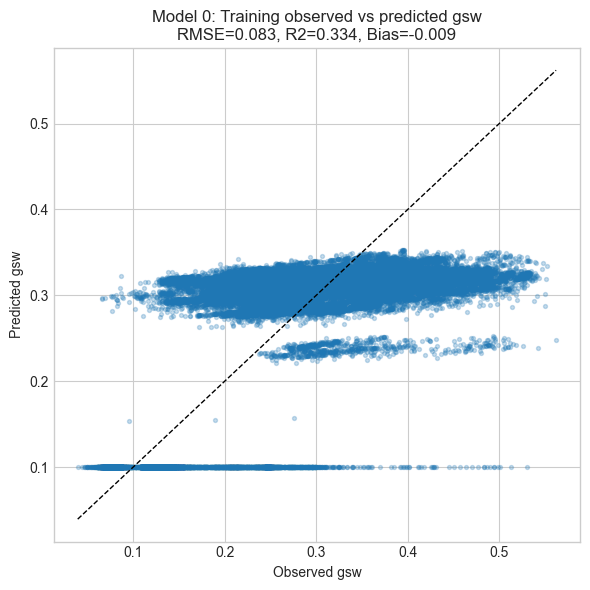

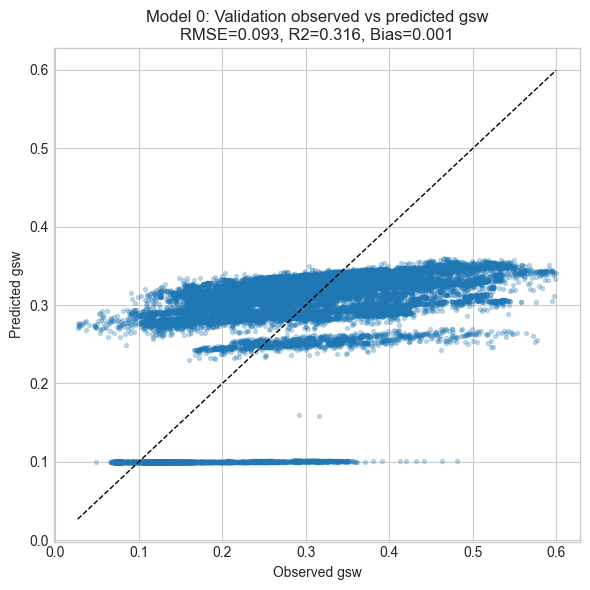

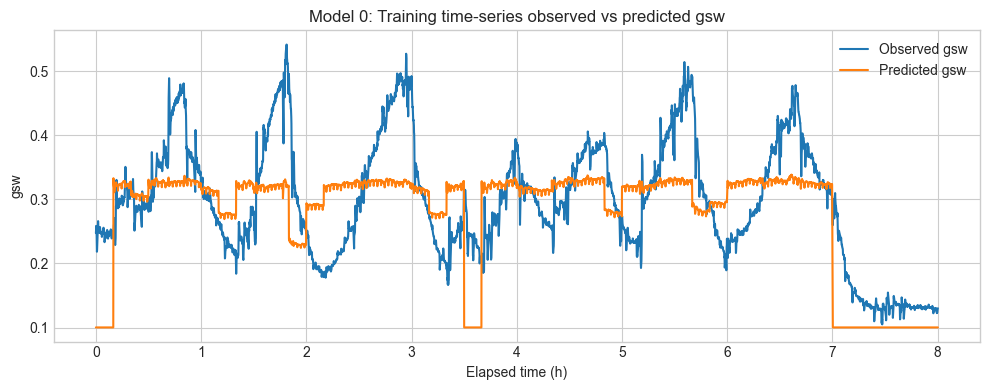

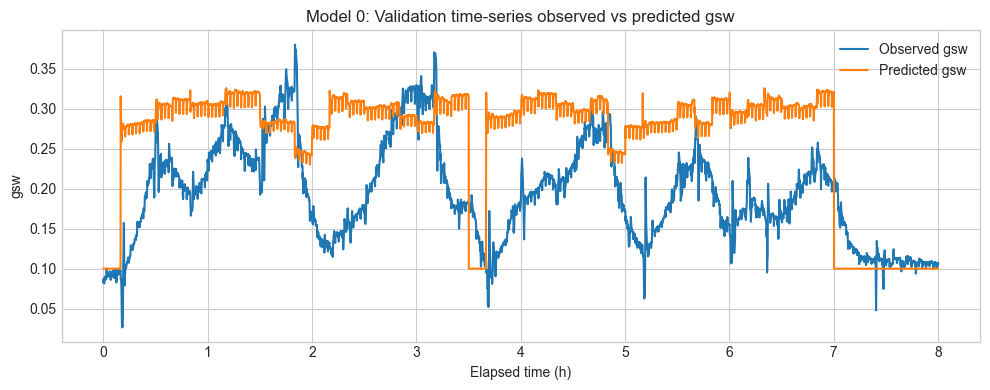

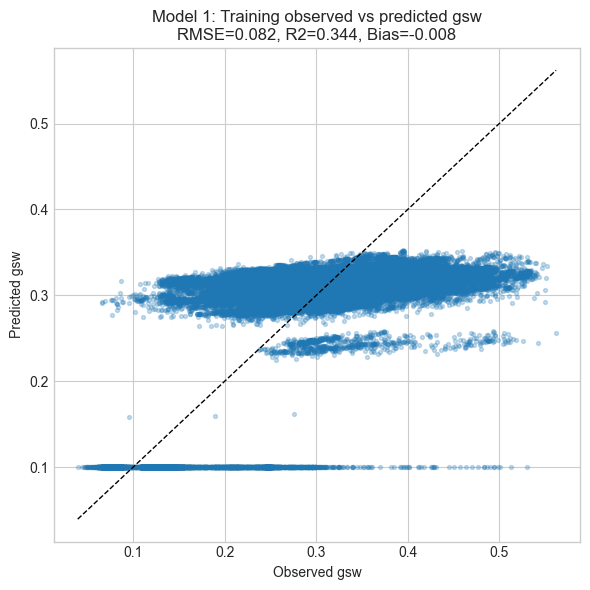

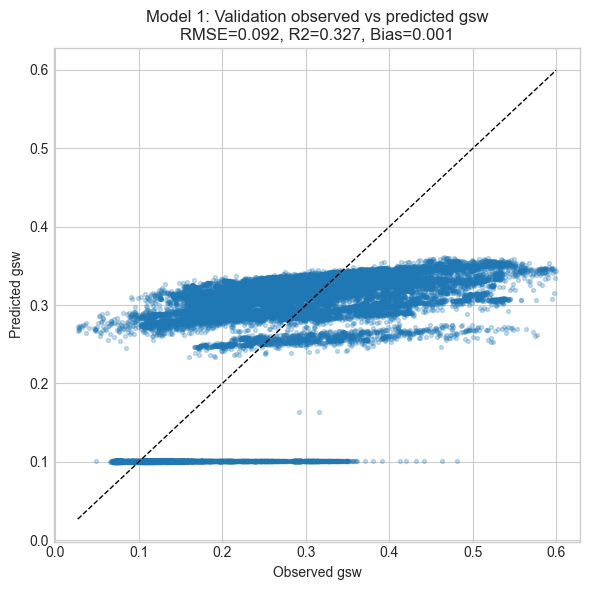

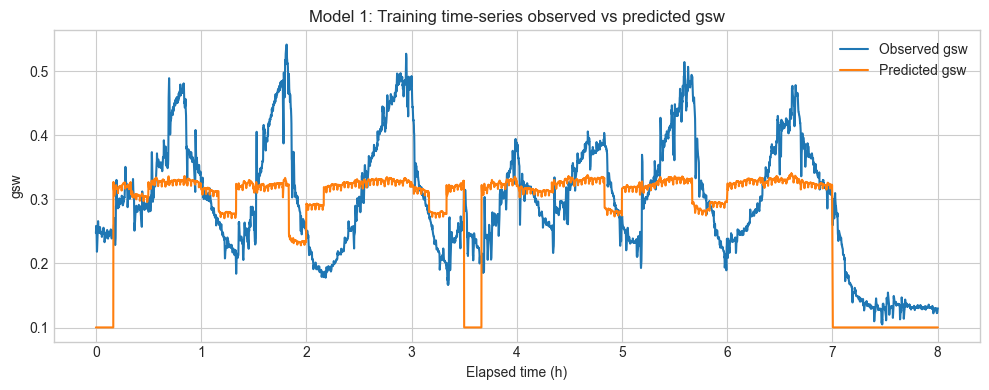

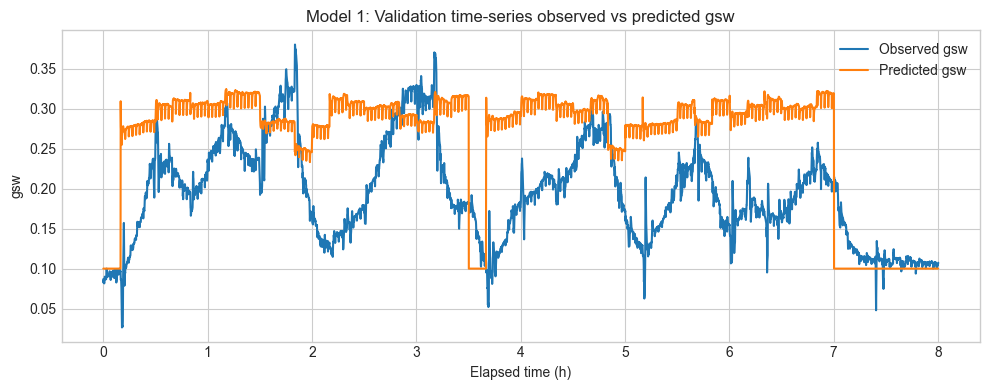

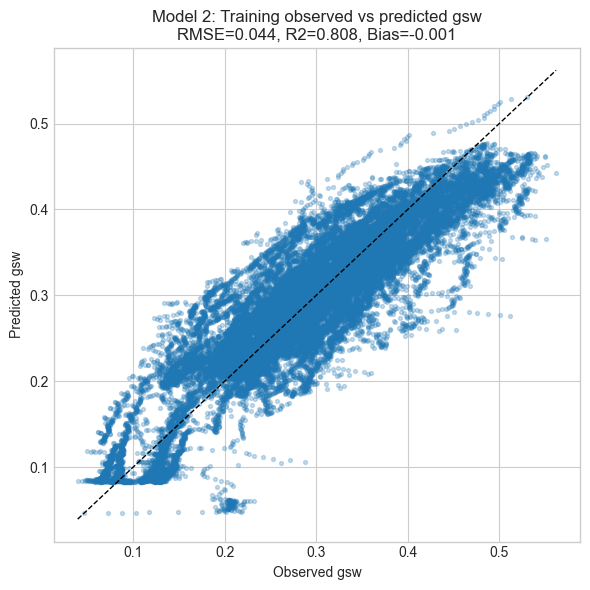

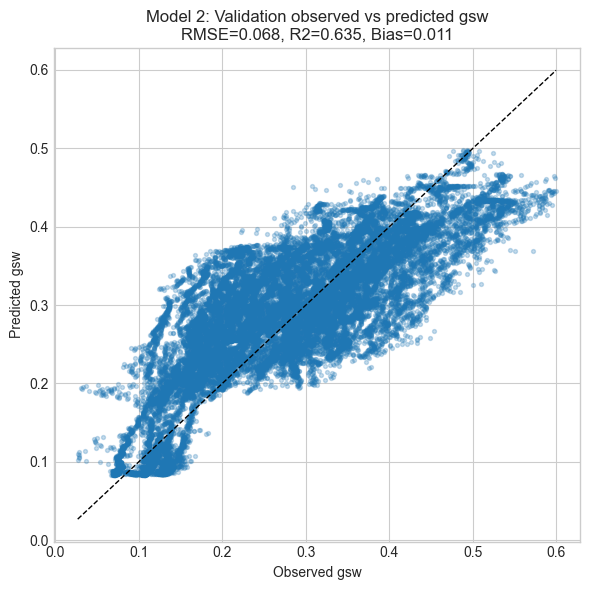

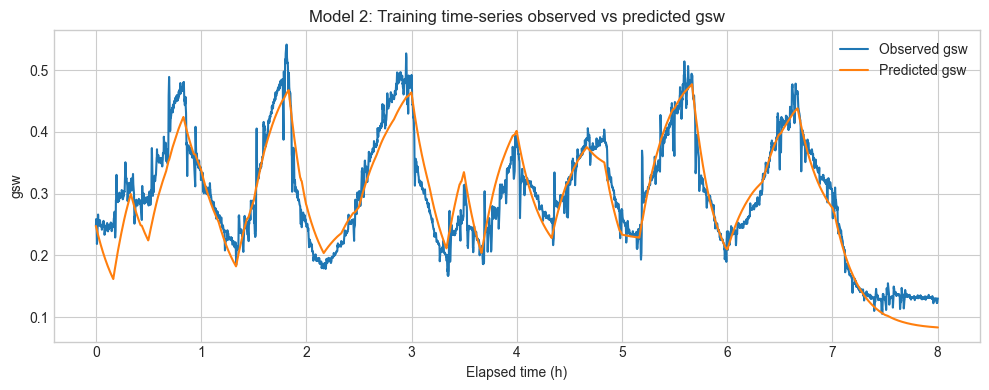

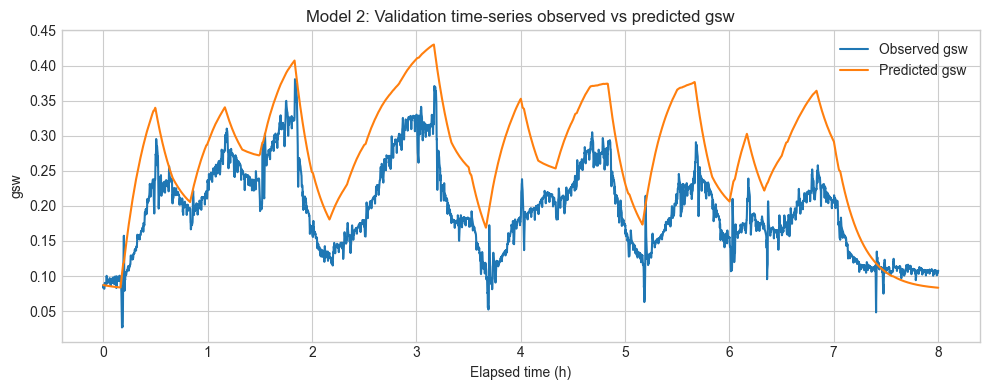

In [8]:
def plot_observed_vs_predicted(y_obs, y_pred, title):
    metrics = calculate_metrics(y_obs, y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_obs, y_pred, s=8, alpha=0.25)
    lim_min = min(np.nanmin(y_obs), np.nanmin(y_pred))
    lim_max = max(np.nanmax(y_obs), np.nanmax(y_pred))
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", linewidth=1)
    plt.xlabel("Observed gsw")
    plt.ylabel("Predicted gsw")
    plt.title(f"{title}\nRMSE={metrics['RMSE']:.3f}, R2={metrics['R2']:.3f}, Bias={metrics['Bias']:.3f}")
    plt.tight_layout()
    plt.show()


def plot_timeseries(df, y_pred, title):
    plot_df = df.copy()
    plot_df["gsw_pred"] = y_pred

    if "_file" in plot_df.columns:
        first_file = plot_df["_file"].iloc[0]
        plot_df = plot_df[plot_df["_file"] == first_file].copy()

    if "elapsed" in plot_df.columns:
        x = plot_df["elapsed"] / 3600
        xlabel = "Elapsed time (h)"
    else:
        x = np.arange(len(plot_df))
        xlabel = "Observation index"

    plt.figure(figsize=(10, 4))
    plt.plot(x, plot_df["gsw"], label="Observed gsw", linewidth=1.5)
    plt.plot(x, plot_df["gsw_pred"], label="Predicted gsw", linewidth=1.5)
    plt.xlabel(xlabel)
    plt.ylabel("gsw")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


predictions = {}

for model_name, params in fitted_params.items():
    param_array = params_to_array(model_name, params)
    predictions[(model_name, "Training")] = predict_model(model_name, param_array, train_df)
    predictions[(model_name, "Validation")] = predict_model(model_name, param_array, validation_df)

    plot_observed_vs_predicted(
        train_df["gsw"],
        predictions[(model_name, "Training")],
        f"{model_name}: Training observed vs predicted gsw",
    )
    plot_observed_vs_predicted(
        validation_df["gsw"],
        predictions[(model_name, "Validation")],
        f"{model_name}: Validation observed vs predicted gsw",
    )

    plot_timeseries(
        train_df,
        predictions[(model_name, "Training")],
        f"{model_name}: Training time-series observed vs predicted gsw",
    )
    plot_timeseries(
        validation_df,
        predictions[(model_name, "Validation")],
        f"{model_name}: Validation time-series observed vs predicted gsw",
    )

## Model 3: Asymmetric Dynamic Leuning Model

Model 3 extends the dynamic Leuning model by allowing separate response speeds for stomatal opening and closing. This is motivated by the fact that stomatal responses under fluctuating environmental conditions may deviate from steady-state assumptions. The model does not assume that opening is faster or slower than closing; instead, it estimates `k_open` and `k_close` from the training data.

The model structure is:

1. Simulate photosynthesis from light:

```text
A_model = (Amax * Qin) / (K + Qin) - Rd
```

2. Calculate the Leuning target conductance:

```text
gsw_target = g0 + gL * A_model / ((1 + VPDleaf / D0) * (Ca - Gamma))
```

3. Apply asymmetric stomatal dynamics:

```text
if gsw_target[t] > gsw_dynamic[t-1]:
    k = k_open
else:
    k = k_close

gsw_dynamic[t] = gsw_dynamic[t-1] + k * (gsw_target[t] - gsw_dynamic[t-1])
```

This optional model tests whether the data support different opening and closing response speeds.

In [9]:
MODEL_3_SPEC = {
    "names": ["Amax", "K", "Rd", "g0", "gL", "Gamma", "D0", "k_open", "k_close"],
    "lower": [0, 1, 0, 0, 0, 0, 0.01, 0.001, 0.001],
    "upper": [35, 3000, 10, 0.1, 50, 100, 10, 1, 1],
    "initial": [25, 500, 2, 0.02, 10, 40, 1.5, 0.75, 0.5],
}


def asymmetric_dynamic_leuning_model(df, params):
    """Model 3: Leuning target with separate opening and closing lag parameters."""
    Amax, K, Rd, g0, gL, Gamma, D0, k_open, k_close = params
    target_params = [Amax, K, Rd, g0, gL, Gamma, D0]

    output = pd.Series(index=df.index, dtype=float)
    groups = df.groupby("_file", sort=False) if "_file" in df.columns else [(None, df)]

    for _, group in groups:
        target = leuning_1995_model(group["Qin"], group["Ca"], group["VPDleaf"], target_params)
        target = np.asarray(target, dtype=float)

        dynamic = np.empty_like(target)
        if len(target) == 0:
            continue

        dynamic[0] = np.clip(group["gsw"].iloc[0], 0, 0.6)
        for i in range(1, len(target)):
            if target[i] > dynamic[i - 1]:
                k = k_open
            else:
                k = k_close
            dynamic[i] = dynamic[i - 1] + k * (target[i] - dynamic[i - 1])

        output.loc[group.index] = dynamic

    return output.to_numpy()


def fit_model_3_asymmetric_dynamic(train_df):
    """Fit Model 3 parameters on Training data only."""
    y_obs = train_df["gsw"].to_numpy(dtype=float)

    def residuals(params):
        y_pred = asymmetric_dynamic_leuning_model(train_df, params)
        residual = y_pred - y_obs
        return np.nan_to_num(residual, nan=1e3, posinf=1e3, neginf=-1e3)

    result = least_squares(
        residuals,
        x0=np.asarray(MODEL_3_SPEC["initial"], dtype=float),
        bounds=(np.asarray(MODEL_3_SPEC["lower"], dtype=float), np.asarray(MODEL_3_SPEC["upper"], dtype=float)),
        max_nfev=700,
        loss="soft_l1",
    )

    params = dict(zip(MODEL_3_SPEC["names"], result.x))
    return params, result


def model_3_params_to_array(params):
    return np.asarray([params[name] for name in MODEL_3_SPEC["names"]], dtype=float)


def evaluate_model_3(params, train_df, validation_df):
    param_array = model_3_params_to_array(params)
    rows = []

    for dataset_name, df in [("Training", train_df), ("Validation", validation_df)]:
        y_pred = asymmetric_dynamic_leuning_model(df, param_array)
        metrics = calculate_metrics(df["gsw"], y_pred)
        rows.append({"Model": "Model 3", "Dataset": dataset_name, **metrics})

    return pd.DataFrame(rows)


model_3_params, model_3_result = fit_model_3_asymmetric_dynamic(train_df)
model_3_metrics = evaluate_model_3(model_3_params, train_df, validation_df)

print("Model 3 fitted parameters")
for key, value in model_3_params.items():
    print(f"  {key}: {value:.6g}")
print(f"  optimizer cost: {model_3_result.cost:.6g}")
print(f"  function evaluations: {model_3_result.nfev}")

print("\nModel 3 metrics")
display(model_3_metrics.round(4))

Model 3 fitted parameters
  Amax: 35
  K: 1045.04
  Rd: 2.58709e-18
  g0: 0.0937312
  gL: 50
  Gamma: 100
  D0: 0.132428
  k_open: 0.00454586
  k_close: 0.00711688
  optimizer cost: 32.5986
  function evaluations: 61

Model 3 metrics


,Model,Dataset,RMSE,R2,Bias
0,Model 3,Training,0.0441,0.8106,-0.0008
1,Model 3,Validation,0.0686,0.6236,0.0122


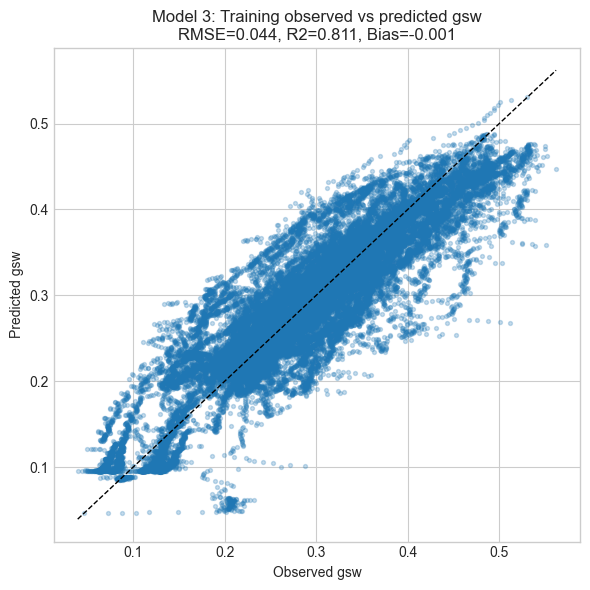

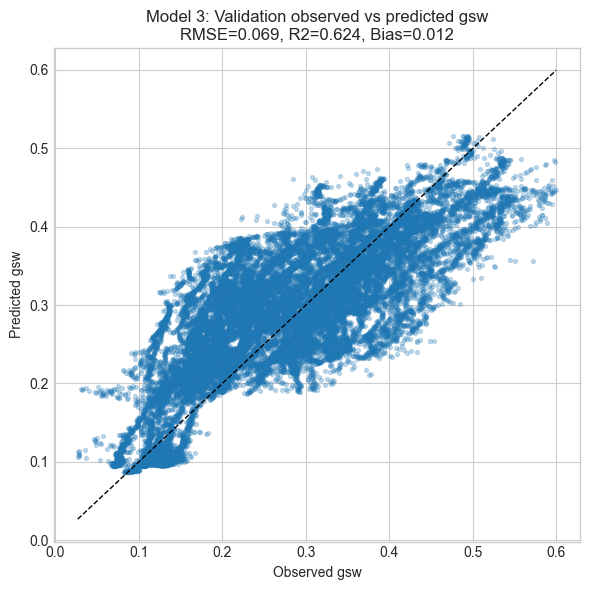

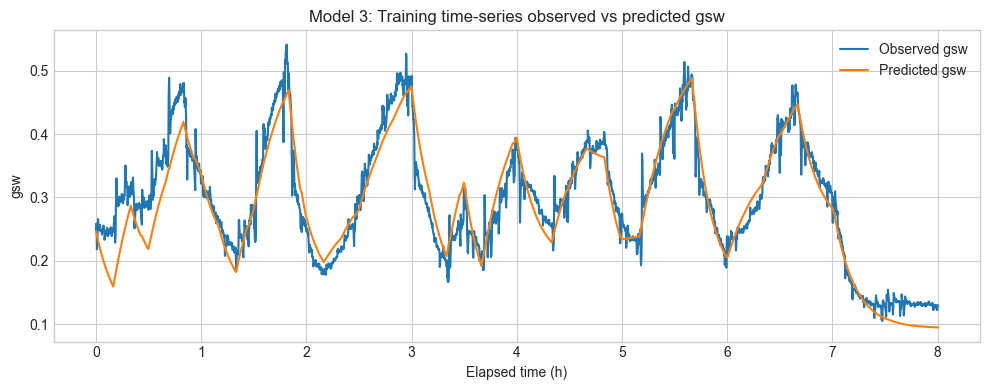

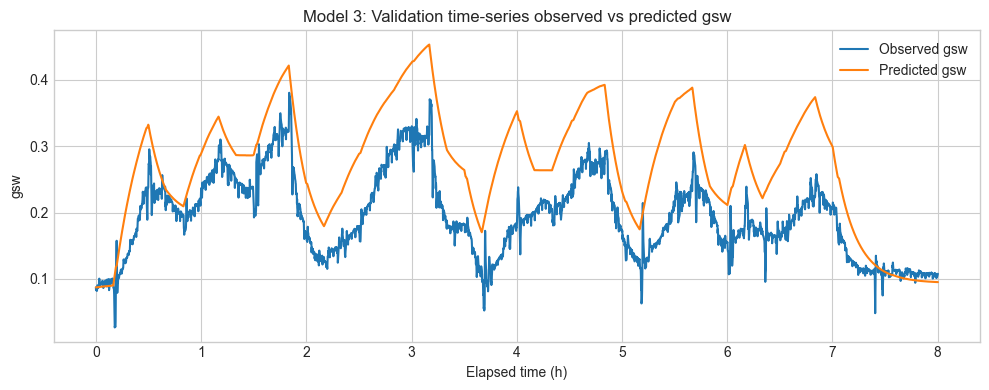

In [10]:
model_3_array = model_3_params_to_array(model_3_params)
model_3_train_pred = asymmetric_dynamic_leuning_model(train_df, model_3_array)
model_3_validation_pred = asymmetric_dynamic_leuning_model(validation_df, model_3_array)

plot_observed_vs_predicted(
    train_df["gsw"],
    model_3_train_pred,
    "Model 3: Training observed vs predicted gsw",
)

plot_observed_vs_predicted(
    validation_df["gsw"],
    model_3_validation_pred,
    "Model 3: Validation observed vs predicted gsw",
)

plot_timeseries(
    train_df,
    model_3_train_pred,
    "Model 3: Training time-series observed vs predicted gsw",
)

plot_timeseries(
    validation_df,
    model_3_validation_pred,
    "Model 3: Validation time-series observed vs predicted gsw",
)

Comparison of all models


,Model,Dataset,RMSE,R2,Bias
0,Model 0,Training,0.0827,0.3341,-0.0086
1,Model 0,Validation,0.0925,0.3161,0.0005
2,Model 1,Training,0.0821,0.3439,-0.0083
3,Model 1,Validation,0.0918,0.3269,0.0008
4,Model 2,Training,0.0444,0.8084,-0.0006
5,Model 2,Validation,0.0676,0.6348,0.0110
6,Model 3,Training,0.0441,0.8106,-0.0008
7,Model 3,Validation,0.0686,0.6236,0.0122


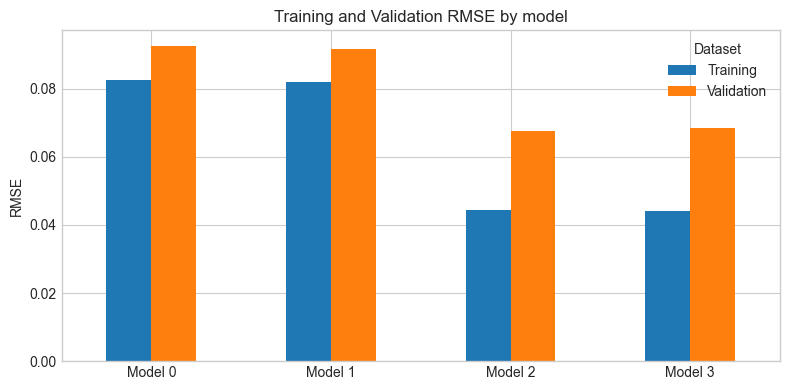

In [11]:
all_model_comparison = pd.concat([comparison_table, model_3_metrics], ignore_index=True)
all_model_comparison[["RMSE", "R2", "Bias"]] = all_model_comparison[["RMSE", "R2", "Bias"]].round(4)

print("Comparison of all models")
display(all_model_comparison)

rmse_plot_df = all_model_comparison.pivot(index="Model", columns="Dataset", values="RMSE")

ax = rmse_plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("RMSE")
ax.set_title("Training and Validation RMSE by model")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Model 3 Interpretation

Model 3 fitted separate lag parameters for stomatal opening and closing after model-specific outlier filtering:

| Parameter | Fitted value | Interpretation |
|---|---:|---|
| `k_open` | 0.0045 | adjustment speed when the Leuning target is above the previous dynamic `gsw` |
| `k_close` | 0.0071 | adjustment speed when the Leuning target is below the previous dynamic `gsw` |

The fitted `k_close` is larger than `k_open`, so in this fitted dataset the model estimated closing to be faster than opening. This was not assumed in advance; both response speeds were estimated from the Training data.

Performance comparison with Model 2:

| Model | Dataset | RMSE | R2 | Bias |
|---|---|---:|---:|---:|
| Model 2 | Training | 0.0444 | 0.8084 | -0.0006 |
| Model 2 | Validation | 0.0676 | 0.6348 | 0.0110 |
| Model 3 | Training | 0.0441 | 0.8106 | -0.0008 |
| Model 3 | Validation | 0.0686 | 0.6236 | 0.0122 |

Model 3 slightly improved Training performance, but it did not improve Validation RMSE or R2 compared with Model 2. This suggests that the extra asymmetric lag parameters may capture small details in the Training data without improving generalization to unseen Validation files. In other words, the current data do not provide strong evidence that asymmetric opening and closing dynamics improve validation performance beyond the simpler dynamic Leuning model.


## Hybrid Residual Model: Model 3 + LSTM Correction

Model 3 captures the main physiological stomatal conductance pattern using a Leuning-based dynamic model. However, remaining errors may arise from leaf-to-leaf variation, unmodelled temporal dynamics, and simplifications in the photosynthesis sub-model. Therefore, a residual LSTM model was added as a hybrid correction. The LSTM does not replace the mechanistic model; it only learns the residual error between observed `gsw` and Model 3 predictions.

The final prediction is calculated as:

```text
gsw_final = gsw_model3 + residual_LSTM
```

Validation observed `gsw` is used only for evaluation. It is not used as an input to generate the LSTM correction.

The residual LSTM uses only variables available during prediction: environmental variables, simulated `A_model`, the mechanistic Model 3 prediction, and elapsed time when available. Measured `A`, observed `gsw`, and validation residuals are not used as LSTM input features.

In [12]:
from sklearn.preprocessing import StandardScaler

HYBRID_SEQUENCE_LENGTH = 30
HYBRID_A_MODEL_DEFAULT_PARAMS = np.asarray([30.268, 398.592, 1.59347], dtype=float)


def get_a_model_feature_params():
    """Return Amax, K, and Rd for the simulated A_model feature."""
    for candidate_name in ["A_params"]:
        if candidate_name in globals():
            candidate = globals()[candidate_name]
            if isinstance(candidate, dict):
                return np.asarray([candidate["Amax"], candidate["K"], candidate["Rd"]], dtype=float)
            candidate = np.asarray(candidate, dtype=float).ravel()
            if len(candidate) >= 3:
                return candidate[:3]
    return HYBRID_A_MODEL_DEFAULT_PARAMS.copy()


def add_a_model_column(df, params):
    """Add simulated photosynthesis from selected A_model parameters if needed."""
    if "A_model" not in df.columns:
        Amax, K, Rd = params
        df["A_model"] = (Amax * df["Qin"]) / (K + df["Qin"]) - Rd
    return df


def get_hybrid_model3_parameter_array():
    """Use existing Model 3 parameters, or refit Model 3 on Training data only if needed."""
    if "fitted_params" in globals() and isinstance(fitted_params, dict) and "Model 3" in fitted_params:
        params = fitted_params["Model 3"]
        if isinstance(params, dict):
            if "MODEL_3_SPEC" in globals():
                return np.asarray([params[name] for name in MODEL_3_SPEC["names"]], dtype=float)
            return np.asarray(list(params.values()), dtype=float)
        return np.asarray(params, dtype=float)

    if "model_3_params" in globals():
        return model_3_params_to_array(model_3_params)

    params, result = fit_model_3_asymmetric_dynamic(train_df)
    globals()["model_3_params"] = params
    globals()["model_3_result"] = result
    return model_3_params_to_array(params)


def predict_model3_for_hybrid(df, model3_param_array):
    """Predict Model 3 while preserving compatibility with the existing notebook API."""
    if "predict_model" in globals():
        try:
            return predict_model("Model 3", model3_param_array, df)
        except Exception:
            pass
    return asymmetric_dynamic_leuning_model(df, model3_param_array)


stage1_photosynthesis_params = get_a_model_feature_params()
model3_hybrid_params = get_hybrid_model3_parameter_array()

train_df = add_a_model_column(train_df, stage1_photosynthesis_params)
validation_df = add_a_model_column(validation_df, stage1_photosynthesis_params)

train_df["gsw_model3"] = predict_model3_for_hybrid(train_df, model3_hybrid_params)
validation_df["gsw_model3"] = predict_model3_for_hybrid(validation_df, model3_hybrid_params)

train_df["residual_model3"] = train_df["gsw"] - train_df["gsw_model3"]
validation_df["residual_model3"] = validation_df["gsw"] - validation_df["gsw_model3"]

HYBRID_FEATURE_COLS = ["Qin", "Ca", "VPDleaf", "Tleaf", "Tair", "RHcham", "A_model", "gsw_model3"]
if "elapsed" in train_df.columns and "elapsed" in validation_df.columns:
    HYBRID_FEATURE_COLS.append("elapsed")

print("Photosynthesis parameters used for A_model feature")
print(dict(zip(["Amax", "K", "Rd"], stage1_photosynthesis_params)))
print()
print("Hybrid LSTM input features")
print(HYBRID_FEATURE_COLS)


def make_lstm_sequences(df, feature_cols, target_col=None, sequence_length=30):
    """Create LSTM sequences without crossing file boundaries."""
    X_list = []
    y_list = []
    index_list = []

    groups = df.groupby("_file", sort=False) if "_file" in df.columns else [(None, df)]

    for _, group in groups:
        group = group.copy()
        if "elapsed" in group.columns:
            group = group.sort_values("elapsed")

        required_cols = list(feature_cols)
        if target_col is not None:
            required_cols.append(target_col)
        group = group.replace([np.inf, -np.inf], np.nan).dropna(subset=required_cols)

        if len(group) < sequence_length:
            continue

        features = group[feature_cols].to_numpy(dtype=np.float32)
        target = group[target_col].to_numpy(dtype=np.float32) if target_col is not None else None
        indices = group.index.to_numpy()

        for end_idx in range(sequence_length - 1, len(group)):
            start_idx = end_idx - sequence_length + 1
            X_list.append(features[start_idx:end_idx + 1])
            index_list.append(indices[end_idx])
            if target_col is not None:
                y_list.append(target[end_idx])

    X = np.asarray(X_list, dtype=np.float32)
    y = None if target_col is None else np.asarray(y_list, dtype=np.float32).reshape(-1, 1)
    row_indices = np.asarray(index_list)
    return X, y, row_indices


feature_scaler = StandardScaler()
feature_scaler.fit(train_df[HYBRID_FEATURE_COLS].replace([np.inf, -np.inf], np.nan).dropna())

HYBRID_SCALED_FEATURE_COLS = [f"{col}_scaled_for_lstm" for col in HYBRID_FEATURE_COLS]
train_df[HYBRID_SCALED_FEATURE_COLS] = feature_scaler.transform(train_df[HYBRID_FEATURE_COLS])
validation_df[HYBRID_SCALED_FEATURE_COLS] = feature_scaler.transform(validation_df[HYBRID_FEATURE_COLS])

X_train_lstm, y_train_lstm, train_lstm_indices = make_lstm_sequences(
    train_df,
    HYBRID_SCALED_FEATURE_COLS,
    target_col="residual_model3",
    sequence_length=HYBRID_SEQUENCE_LENGTH,
)
X_validation_lstm, _, validation_lstm_indices = make_lstm_sequences(
    validation_df,
    HYBRID_SCALED_FEATURE_COLS,
    target_col=None,
    sequence_length=HYBRID_SEQUENCE_LENGTH,
)

print(f"Training LSTM sequences: {X_train_lstm.shape}")
print(f"Validation LSTM sequences: {X_validation_lstm.shape}")

Photosynthesis parameters used for A_model feature
{'Amax': np.float64(30.268), 'K': np.float64(398.592), 'Rd': np.float64(1.59347)}

Hybrid LSTM input features
['Qin', 'Ca', 'VPDleaf', 'Tleaf', 'Tair', 'RHcham', 'A_model', 'gsw_model3', 'elapsed']


Training LSTM sequences: (33389, 30, 9)
Validation LSTM sequences: (27500, 30, 9)


Epoch 01/40, training MSE loss = 0.001601


Epoch 05/40, training MSE loss = 0.000627


Epoch 10/40, training MSE loss = 0.000430


Epoch 15/40, training MSE loss = 0.000319


Epoch 20/40, training MSE loss = 0.000247


Epoch 25/40, training MSE loss = 0.000218


Epoch 30/40, training MSE loss = 0.000180


Epoch 35/40, training MSE loss = 0.000175


Epoch 40/40, training MSE loss = 0.000153


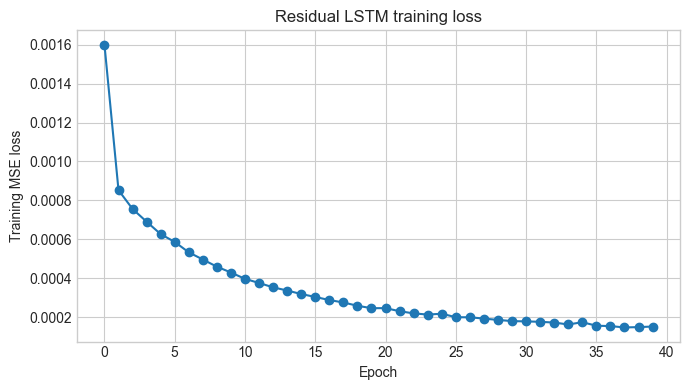

In [13]:
try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "PyTorch is required for the hybrid residual LSTM section. "
        "Install torch in the active notebook environment, then rerun this section."
    ) from exc


torch.manual_seed(42)
np.random.seed(42)


class ResidualLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_state = lstm_out[:, -1, :]
        return self.output(last_state)


def train_residual_lstm(X, y, epochs=40, batch_size=128, learning_rate=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResidualLSTM(input_size=X.shape[2], hidden_size=32, num_layers=1, dropout=0.0).to(device)

    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_obs = 0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(X_batch)
            n_obs += len(X_batch)

        epoch_loss = running_loss / max(n_obs, 1)
        history.append(epoch_loss)
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"Epoch {epoch:02d}/{epochs}, training MSE loss = {epoch_loss:.6f}")

    return model, history, device


def predict_lstm_residuals(model, X, device, batch_size=512):
    model.eval()
    preds = []
    loader = DataLoader(torch.tensor(X, dtype=torch.float32), batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())

    return np.vstack(preds).ravel()


residual_lstm_model, residual_lstm_history, residual_lstm_device = train_residual_lstm(
    X_train_lstm,
    y_train_lstm,
    epochs=40,
    batch_size=128,
    learning_rate=0.001,
)

train_residual_lstm_pred = predict_lstm_residuals(residual_lstm_model, X_train_lstm, residual_lstm_device)
validation_residual_lstm_pred = predict_lstm_residuals(residual_lstm_model, X_validation_lstm, residual_lstm_device)

train_df["residual_lstm_pred"] = np.nan
validation_df["residual_lstm_pred"] = np.nan
train_df.loc[train_lstm_indices, "residual_lstm_pred"] = train_residual_lstm_pred
validation_df.loc[validation_lstm_indices, "residual_lstm_pred"] = validation_residual_lstm_pred

train_df["gsw_model3_lstm"] = train_df["gsw_model3"] + train_df["residual_lstm_pred"]
validation_df["gsw_model3_lstm"] = validation_df["gsw_model3"] + validation_df["residual_lstm_pred"]

plt.figure(figsize=(7, 4))
plt.plot(residual_lstm_history, marker="o", linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Training MSE loss")
plt.title("Residual LSTM training loss")
plt.tight_layout()
plt.show()


Model 3 vs Model 3 + LSTM residual comparison


,Model,Dataset,RMSE,R2,Bias
0,Model 3,Training,0.0440,0.8114,-0.0008
1,Model 3 + LSTM residual,Training,0.0144,0.9798,-0.0030
2,Model 3,Validation,0.0688,0.6215,0.0123
3,Model 3 + LSTM residual,Validation,0.0604,0.7080,0.0086


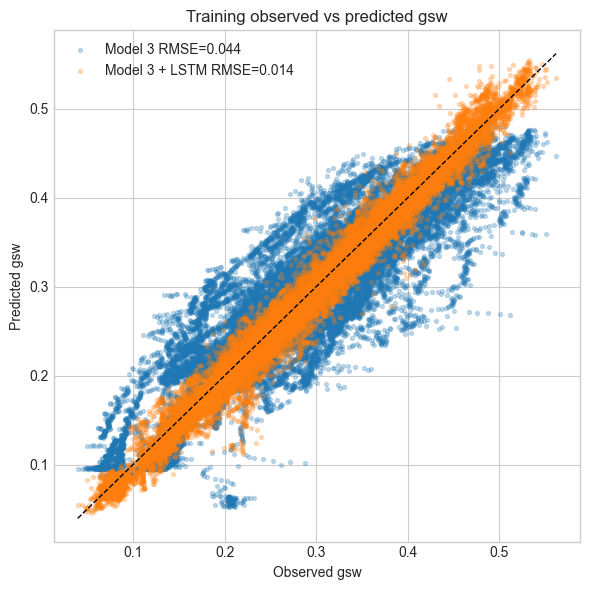

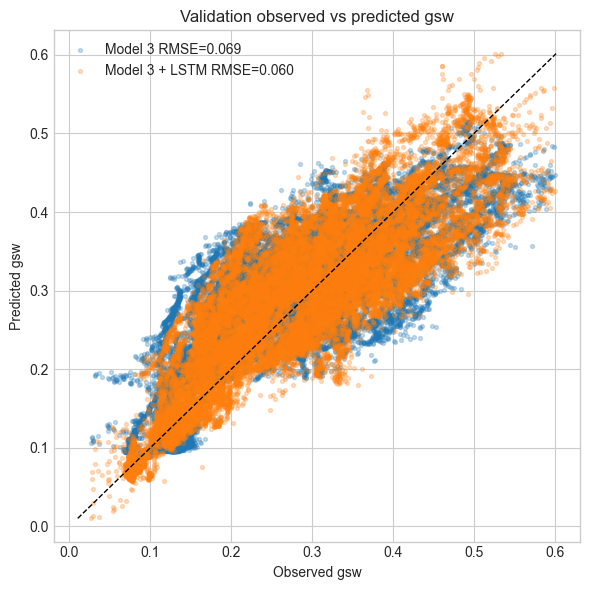

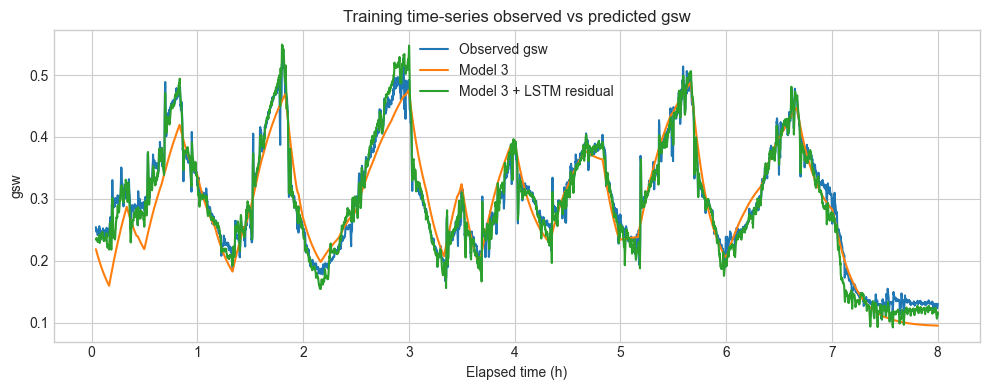

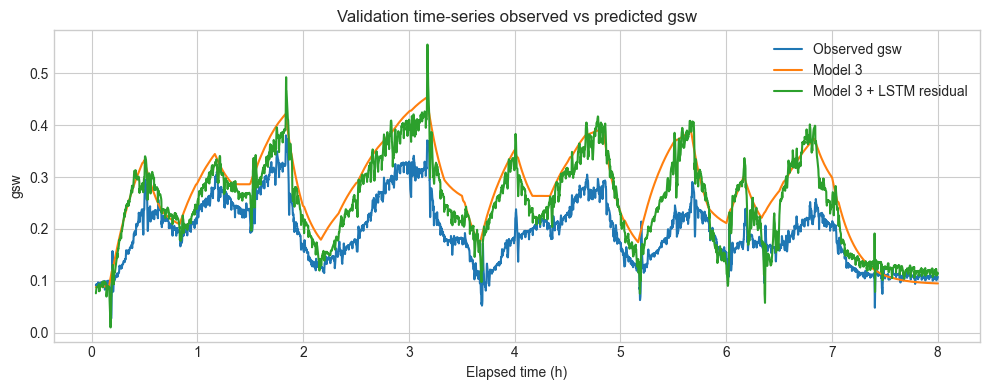

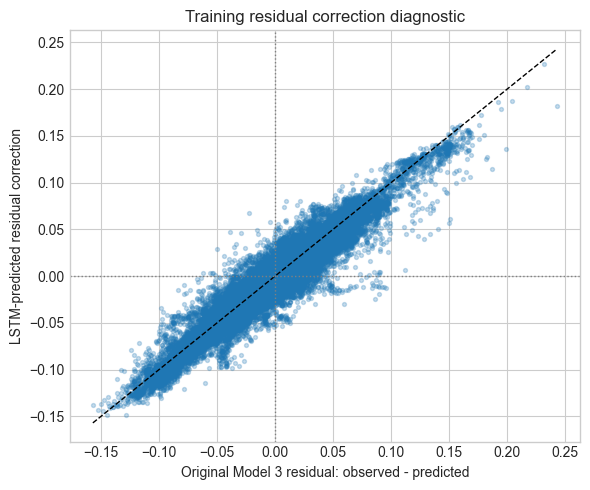

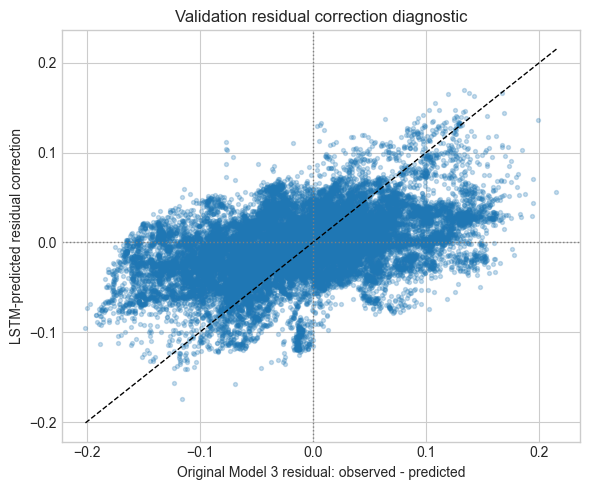

In [14]:
def calculate_metrics_on_available_rows(df, prediction_col):
    mask = df[prediction_col].notna() & df["gsw"].notna()
    return calculate_metrics(df.loc[mask, "gsw"], df.loc[mask, prediction_col])


def build_hybrid_comparison_table(train_df, validation_df):
    rows = []
    for dataset_name, df in [("Training", train_df), ("Validation", validation_df)]:
        available = df["gsw_model3_lstm"].notna()
        model3_metrics = calculate_metrics(df.loc[available, "gsw"], df.loc[available, "gsw_model3"])
        hybrid_metrics = calculate_metrics(df.loc[available, "gsw"], df.loc[available, "gsw_model3_lstm"])
        rows.append({"Model": "Model 3", "Dataset": dataset_name, **model3_metrics})
        rows.append({"Model": "Model 3 + LSTM residual", "Dataset": dataset_name, **hybrid_metrics})
    return pd.DataFrame(rows)


hybrid_lstm_comparison = build_hybrid_comparison_table(train_df, validation_df)
hybrid_lstm_comparison_display = hybrid_lstm_comparison.copy()
hybrid_lstm_comparison_display[["RMSE", "R2", "Bias"]] = hybrid_lstm_comparison_display[["RMSE", "R2", "Bias"]].round(4)

print("Model 3 vs Model 3 + LSTM residual comparison")
display(hybrid_lstm_comparison_display)


def plot_hybrid_observed_vs_predicted(df, dataset_name):
    plot_df = df.dropna(subset=["gsw", "gsw_model3", "gsw_model3_lstm"]).copy()
    metrics_model3 = calculate_metrics(plot_df["gsw"], plot_df["gsw_model3"])
    metrics_hybrid = calculate_metrics(plot_df["gsw"], plot_df["gsw_model3_lstm"])

    lim_min = np.nanmin([plot_df["gsw"].min(), plot_df["gsw_model3"].min(), plot_df["gsw_model3_lstm"].min()])
    lim_max = np.nanmax([plot_df["gsw"].max(), plot_df["gsw_model3"].max(), plot_df["gsw_model3_lstm"].max()])

    plt.figure(figsize=(6, 6))
    plt.scatter(plot_df["gsw"], plot_df["gsw_model3"], s=8, alpha=0.25, label=f"Model 3 RMSE={metrics_model3['RMSE']:.3f}")
    plt.scatter(plot_df["gsw"], plot_df["gsw_model3_lstm"], s=8, alpha=0.25, label=f"Model 3 + LSTM RMSE={metrics_hybrid['RMSE']:.3f}")
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", linewidth=1)
    plt.xlabel("Observed gsw")
    plt.ylabel("Predicted gsw")
    plt.title(f"{dataset_name} observed vs predicted gsw")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_hybrid_timeseries(df, dataset_name):
    plot_df = df.dropna(subset=["gsw", "gsw_model3", "gsw_model3_lstm"]).copy()
    if "_file" in plot_df.columns:
        first_file = plot_df["_file"].iloc[0]
        plot_df = plot_df[plot_df["_file"] == first_file].copy()
    if "elapsed" in plot_df.columns:
        plot_df = plot_df.sort_values("elapsed")
        x = plot_df["elapsed"] / 3600
        xlabel = "Elapsed time (h)"
    else:
        x = np.arange(len(plot_df))
        xlabel = "Observation index"

    plt.figure(figsize=(10, 4))
    plt.plot(x, plot_df["gsw"], label="Observed gsw", linewidth=1.5)
    plt.plot(x, plot_df["gsw_model3"], label="Model 3", linewidth=1.5)
    plt.plot(x, plot_df["gsw_model3_lstm"], label="Model 3 + LSTM residual", linewidth=1.5)
    plt.xlabel(xlabel)
    plt.ylabel("gsw")
    plt.title(f"{dataset_name} time-series observed vs predicted gsw")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_residual_correction(df, dataset_name):
    plot_df = df.dropna(subset=["residual_model3", "residual_lstm_pred"]).copy()
    lim_min = np.nanmin([plot_df["residual_model3"].min(), plot_df["residual_lstm_pred"].min()])
    lim_max = np.nanmax([plot_df["residual_model3"].max(), plot_df["residual_lstm_pred"].max()])

    plt.figure(figsize=(6, 5))
    plt.scatter(plot_df["residual_model3"], plot_df["residual_lstm_pred"], s=8, alpha=0.25)
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", linewidth=1)
    plt.axhline(0, color="grey", linestyle=":", linewidth=1)
    plt.axvline(0, color="grey", linestyle=":", linewidth=1)
    plt.xlabel("Original Model 3 residual: observed - predicted")
    plt.ylabel("LSTM-predicted residual correction")
    plt.title(f"{dataset_name} residual correction diagnostic")
    plt.tight_layout()
    plt.show()


plot_hybrid_observed_vs_predicted(train_df, "Training")
plot_hybrid_observed_vs_predicted(validation_df, "Validation")
plot_hybrid_timeseries(train_df, "Training")
plot_hybrid_timeseries(validation_df, "Validation")
plot_residual_correction(train_df, "Training")
plot_residual_correction(validation_df, "Validation")


## Simple Residual Correction: Model 3 + Ridge Residual

Because the LSTM residual model fitted the training residuals very well but showed limited validation improvement, a simpler residual correction was tested using Ridge regression. Ridge regression is less flexible than LSTM and may generalize better when the number of independent leaf-level time series is limited. This residual model does not replace the mechanistic Model 3; it only corrects systematic residual patterns.

The corrected prediction is:

```text
gsw_model3_ridge = gsw_model3 + residual_ridge_pred
```

The Ridge model is fitted only on Training residuals. Measured `A`, observed `gsw`, and Validation residuals are not used as Ridge input features.

In [15]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

RIDGE_ALPHA_VALUES = [0.1, 1, 10, 100]
RIDGE_DEFAULT_ALPHA = 10


def get_ridge_a_model_feature_params():
    for candidate_name in ["A_params"]:
        if candidate_name in globals():
            candidate = globals()[candidate_name]
            if isinstance(candidate, dict):
                return np.asarray([candidate["Amax"], candidate["K"], candidate["Rd"]], dtype=float)
            candidate = np.asarray(candidate, dtype=float).ravel()
            if len(candidate) >= 3:
                return candidate[:3]
    return np.asarray([30.268, 398.592, 1.59347], dtype=float)


def add_ridge_a_model_if_needed(df, params):
    if "A_model" not in df.columns:
        Amax, K, Rd = params
        df["A_model"] = (Amax * df["Qin"]) / (K + df["Qin"]) - Rd
    return df


def get_ridge_model3_parameter_array():
    if "get_hybrid_model3_parameter_array" in globals():
        return get_hybrid_model3_parameter_array()
    if "fitted_params" in globals() and isinstance(fitted_params, dict) and "Model 3" in fitted_params:
        params = fitted_params["Model 3"]
        if isinstance(params, dict):
            if "MODEL_3_SPEC" in globals():
                return np.asarray([params[name] for name in MODEL_3_SPEC["names"]], dtype=float)
            return np.asarray(list(params.values()), dtype=float)
        return np.asarray(params, dtype=float)
    if "model_3_params" in globals():
        return model_3_params_to_array(model_3_params)
    params, result = fit_model_3_asymmetric_dynamic(train_df)
    globals()["model_3_params"] = params
    globals()["model_3_result"] = result
    return model_3_params_to_array(params)


def predict_ridge_model3(df, model3_param_array):
    if "predict_model3_for_hybrid" in globals():
        return predict_model3_for_hybrid(df, model3_param_array)
    if "predict_model" in globals():
        try:
            return predict_model("Model 3", model3_param_array, df)
        except Exception:
            pass
    return asymmetric_dynamic_leuning_model(df, model3_param_array)


ridge_stage1_params = get_ridge_a_model_feature_params()
train_df = add_ridge_a_model_if_needed(train_df, ridge_stage1_params)
validation_df = add_ridge_a_model_if_needed(validation_df, ridge_stage1_params)

if "gsw_model3" not in train_df.columns or "gsw_model3" not in validation_df.columns:
    ridge_model3_params = get_ridge_model3_parameter_array()
    train_df["gsw_model3"] = predict_ridge_model3(train_df, ridge_model3_params)
    validation_df["gsw_model3"] = predict_ridge_model3(validation_df, ridge_model3_params)

train_df["residual_model3"] = train_df["gsw"] - train_df["gsw_model3"]
validation_df["residual_model3"] = validation_df["gsw"] - validation_df["gsw_model3"]

RIDGE_FEATURE_COLS = ["Qin", "Ca", "VPDleaf", "Tleaf", "Tair", "RHcham", "A_model", "gsw_model3"]
if "elapsed" in train_df.columns and "elapsed" in validation_df.columns:
    RIDGE_FEATURE_COLS.append("elapsed")

ridge_train_required = RIDGE_FEATURE_COLS + ["residual_model3", "gsw", "gsw_model3"]
ridge_validation_required = RIDGE_FEATURE_COLS + ["gsw", "gsw_model3"]
ridge_train_data = train_df.replace([np.inf, -np.inf], np.nan).dropna(subset=ridge_train_required).copy()
ridge_validation_data = validation_df.replace([np.inf, -np.inf], np.nan).dropna(subset=ridge_validation_required).copy()


def select_ridge_alpha_by_file_cv(train_data, feature_cols, alpha_values):
    if "_file" not in train_data.columns or train_data["_file"].nunique() < 2:
        return RIDGE_DEFAULT_ALPHA, pd.DataFrame()

    rows = []
    for alpha in alpha_values:
        fold_rows = []
        for held_out_file, holdout_df in train_data.groupby("_file", sort=False):
            fit_df = train_data[train_data["_file"] != held_out_file]
            if fit_df.empty or holdout_df.empty:
                continue

            scaler = StandardScaler()
            X_fit = scaler.fit_transform(fit_df[feature_cols])
            y_fit = fit_df["residual_model3"].to_numpy(dtype=float)
            X_holdout = scaler.transform(holdout_df[feature_cols])

            model = Ridge(alpha=alpha)
            model.fit(X_fit, y_fit)
            residual_pred = model.predict(X_holdout)
            corrected = np.clip(holdout_df["gsw_model3"].to_numpy(dtype=float) + residual_pred, 0, 0.6)
            metrics = calculate_metrics(holdout_df["gsw"], corrected)
            fold_rows.append({
                "alpha": alpha,
                "held_out_file": held_out_file,
                "Rows": len(holdout_df),
                **metrics,
            })

        if fold_rows:
            rows.extend(fold_rows)

    cv_table = pd.DataFrame(rows)
    if cv_table.empty:
        return RIDGE_DEFAULT_ALPHA, cv_table

    alpha_summary = cv_table.groupby("alpha", as_index=False)["RMSE"].mean().sort_values("RMSE")
    selected_alpha = float(alpha_summary.iloc[0]["alpha"])
    return selected_alpha, cv_table


selected_ridge_alpha, ridge_alpha_cv_table = select_ridge_alpha_by_file_cv(
    ridge_train_data,
    RIDGE_FEATURE_COLS,
    RIDGE_ALPHA_VALUES,
)

ridge_scaler = StandardScaler()
X_ridge_train = ridge_scaler.fit_transform(ridge_train_data[RIDGE_FEATURE_COLS])
y_ridge_train = ridge_train_data["residual_model3"].to_numpy(dtype=float)
X_ridge_validation = ridge_scaler.transform(ridge_validation_data[RIDGE_FEATURE_COLS])

ridge_residual_model = Ridge(alpha=selected_ridge_alpha)
ridge_residual_model.fit(X_ridge_train, y_ridge_train)

train_df["residual_ridge_pred"] = np.nan
validation_df["residual_ridge_pred"] = np.nan
train_df.loc[ridge_train_data.index, "residual_ridge_pred"] = ridge_residual_model.predict(X_ridge_train)
validation_df.loc[ridge_validation_data.index, "residual_ridge_pred"] = ridge_residual_model.predict(X_ridge_validation)

train_df["gsw_model3_ridge"] = np.clip(train_df["gsw_model3"] + train_df["residual_ridge_pred"], 0, 0.6)
validation_df["gsw_model3_ridge"] = np.clip(validation_df["gsw_model3"] + validation_df["residual_ridge_pred"], 0, 0.6)

print("Ridge residual input features")
print(RIDGE_FEATURE_COLS)
print(f"Selected Ridge alpha: {selected_ridge_alpha:g}")

if not ridge_alpha_cv_table.empty:
    ridge_alpha_cv_summary = ridge_alpha_cv_table.groupby("alpha", as_index=False).agg(
        Mean_RMSE=("RMSE", "mean"),
        Mean_R2=("R2", "mean"),
        Mean_Bias=("Bias", "mean"),
    )
    ridge_alpha_cv_summary[["Mean_RMSE", "Mean_R2", "Mean_Bias"]] = ridge_alpha_cv_summary[["Mean_RMSE", "Mean_R2", "Mean_Bias"]].round(4)
    print()
    print("Leave-one-file-out Training CV by alpha")
    display(ridge_alpha_cv_summary)

Ridge residual input features
['Qin', 'Ca', 'VPDleaf', 'Tleaf', 'Tair', 'RHcham', 'A_model', 'gsw_model3', 'elapsed']
Selected Ridge alpha: 100

Leave-one-file-out Training CV by alpha


,alpha,Mean_RMSE,Mean_R2,Mean_Bias
0,0.1,0.0390,0.8384,0.0011
1,1.0,0.0390,0.8391,0.0010
2,10.0,0.0388,0.8404,0.0008
3,100.0,0.0386,0.8417,0.0007


Residual correction comparison


,Model,Dataset,RMSE,R2,Bias
0,Model 3,Training,0.0441,0.8106,-0.0008
1,Model 3 + LSTM residual,Training,0.0144,0.9798,-0.0030
2,Model 3 + Ridge residual,Training,0.0352,0.8791,0.0000
3,Model 3,Validation,0.0686,0.6236,0.0122
4,Model 3 + LSTM residual,Validation,0.0604,0.7080,0.0086
5,Model 3 + Ridge residual,Validation,0.0470,0.8237,0.0098


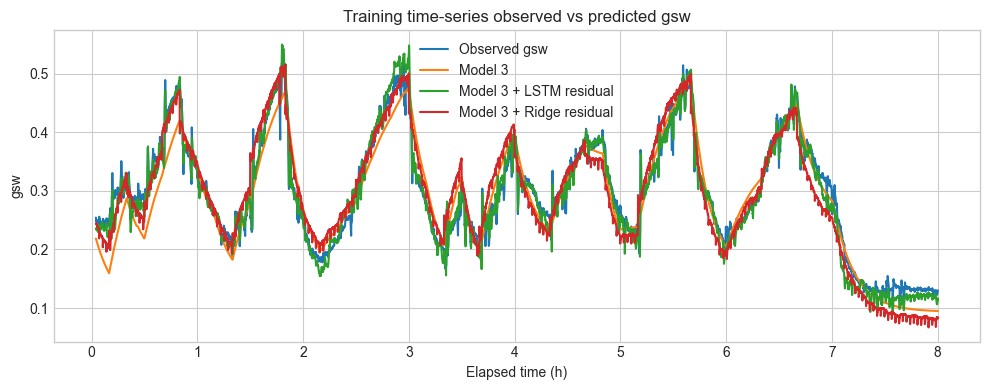

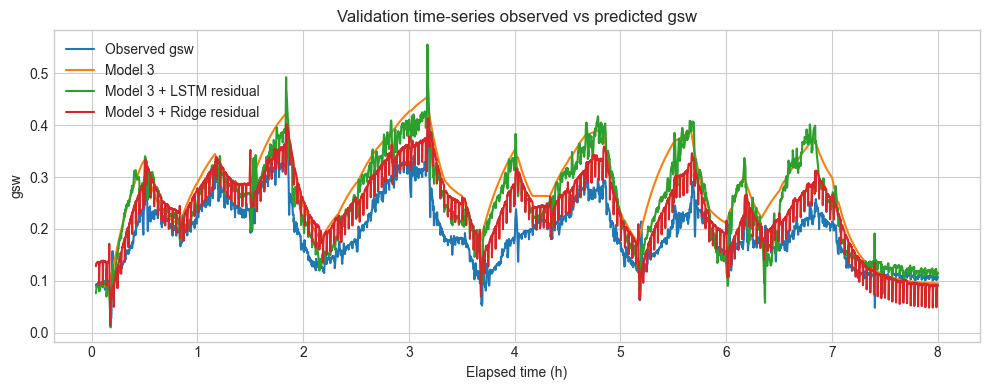

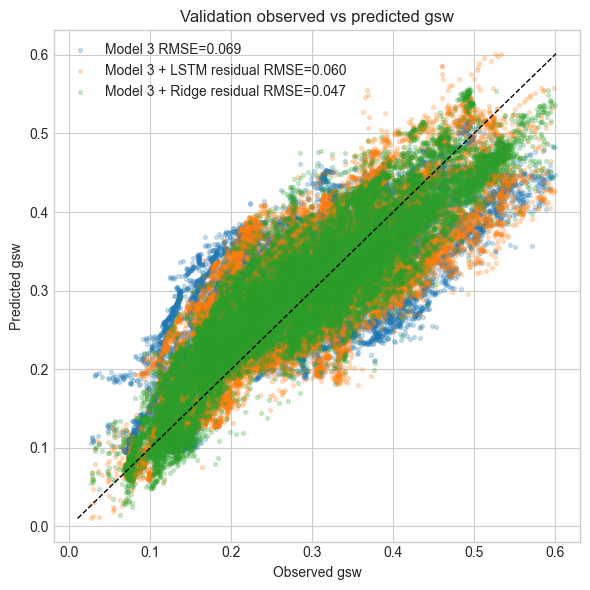

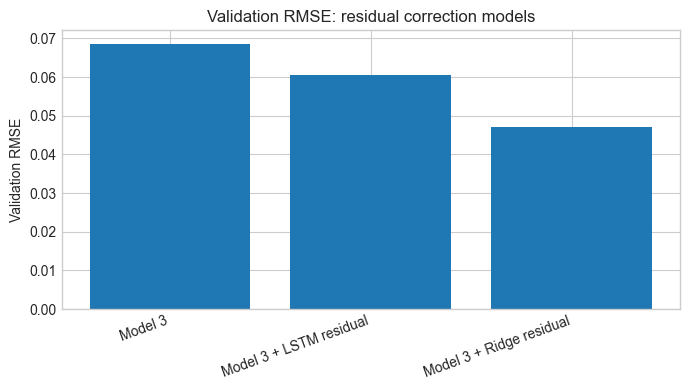

In [16]:
def calculate_available_prediction_metrics(df, prediction_col):
    mask = df[prediction_col].notna() & df["gsw"].notna()
    return calculate_metrics(df.loc[mask, "gsw"], df.loc[mask, prediction_col])


ridge_comparison_rows = []
for dataset_name, df in [("Training", train_df), ("Validation", validation_df)]:
    model_columns = [
        ("Model 3", "gsw_model3"),
        ("Model 3 + LSTM residual", "gsw_model3_lstm"),
        ("Model 3 + Ridge residual", "gsw_model3_ridge"),
    ]
    for model_label, prediction_col in model_columns:
        if prediction_col not in df.columns:
            continue
        metrics = calculate_available_prediction_metrics(df, prediction_col)
        ridge_comparison_rows.append({"Model": model_label, "Dataset": dataset_name, **metrics})

ridge_residual_comparison = pd.DataFrame(ridge_comparison_rows)
ridge_residual_comparison_display = ridge_residual_comparison.copy()
ridge_residual_comparison_display[["RMSE", "R2", "Bias"]] = ridge_residual_comparison_display[["RMSE", "R2", "Bias"]].round(4)

print("Residual correction comparison")
display(ridge_residual_comparison_display)


def plot_ridge_correction_timeseries(df, dataset_name):
    plot_cols = ["gsw", "gsw_model3", "gsw_model3_ridge"]
    include_lstm = "gsw_model3_lstm" in df.columns
    if include_lstm:
        plot_cols.append("gsw_model3_lstm")

    plot_df = df.dropna(subset=[col for col in plot_cols if col in df.columns]).copy()
    if plot_df.empty:
        print(f"No complete rows available for {dataset_name} time-series plot.")
        return

    if "_file" in plot_df.columns:
        first_file = plot_df["_file"].iloc[0]
        plot_df = plot_df[plot_df["_file"] == first_file].copy()
    if "elapsed" in plot_df.columns:
        plot_df = plot_df.sort_values("elapsed")
        x = plot_df["elapsed"] / 3600
        xlabel = "Elapsed time (h)"
    else:
        x = np.arange(len(plot_df))
        xlabel = "Observation index"

    plt.figure(figsize=(10, 4))
    plt.plot(x, plot_df["gsw"], label="Observed gsw", linewidth=1.5)
    plt.plot(x, plot_df["gsw_model3"], label="Model 3", linewidth=1.5)
    if include_lstm:
        plt.plot(x, plot_df["gsw_model3_lstm"], label="Model 3 + LSTM residual", linewidth=1.5)
    plt.plot(x, plot_df["gsw_model3_ridge"], label="Model 3 + Ridge residual", linewidth=1.5)
    plt.xlabel(xlabel)
    plt.ylabel("gsw")
    plt.title(f"{dataset_name} time-series observed vs predicted gsw")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_validation_ridge_scatter(validation_df):
    model_columns = [
        ("Model 3", "gsw_model3"),
        ("Model 3 + LSTM residual", "gsw_model3_lstm"),
        ("Model 3 + Ridge residual", "gsw_model3_ridge"),
    ]
    available_cols = [(label, col) for label, col in model_columns if col in validation_df.columns]
    plot_df = validation_df.dropna(subset=["gsw"] + [col for _, col in available_cols]).copy()
    if plot_df.empty:
        print("No complete rows available for Validation scatter plot.")
        return

    lim_min = min([plot_df["gsw"].min()] + [plot_df[col].min() for _, col in available_cols])
    lim_max = max([plot_df["gsw"].max()] + [plot_df[col].max() for _, col in available_cols])

    plt.figure(figsize=(6, 6))
    for label, col in available_cols:
        metrics = calculate_metrics(plot_df["gsw"], plot_df[col])
        plt.scatter(plot_df["gsw"], plot_df[col], s=8, alpha=0.22, label=f"{label} RMSE={metrics['RMSE']:.3f}")
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", linewidth=1)
    plt.xlabel("Observed gsw")
    plt.ylabel("Predicted gsw")
    plt.title("Validation observed vs predicted gsw")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_validation_rmse_bar(comparison_table):
    validation_rmse = comparison_table[comparison_table["Dataset"] == "Validation"].copy()
    plt.figure(figsize=(7, 4))
    plt.bar(validation_rmse["Model"], validation_rmse["RMSE"])
    plt.ylabel("Validation RMSE")
    plt.title("Validation RMSE: residual correction models")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


plot_ridge_correction_timeseries(train_df, "Training")
plot_ridge_correction_timeseries(validation_df, "Validation")
plot_validation_ridge_scatter(validation_df)
plot_validation_rmSE_table = ridge_residual_comparison.copy()
plot_validation_rmse_bar(plot_validation_rmSE_table)


## Introduction & Context

Stomatal conductance to water vapour (`gsw`) controls both CO2 uptake for photosynthesis and water loss through transpiration. This creates a biological trade-off: opening stomata can increase carbon gain, but it also increases water loss. The modelling goal of this assignment is to predict `gsw` under fluctuating light conditions using environmental drivers, especially incident light (`Qin`), ambient CO2 (`Ca`), and leaf-to-air vapour pressure deficit (`VPDleaf`).

## Dataset Description

The dataset consists of LI-COR 6800 gas exchange measurements collected under fluctuating light. The Training dataset contains 6 files and 33,923 rows, while the Validation dataset contains 5 files and 28,303 rows before the final modelling-specific filters. The target variable is stomatal conductance to water vapour (`gsw`). The main model inputs are `Qin`, `Ca`, and `VPDleaf`, with additional available environmental variables including `Tleaf`, `Tair`, and `RHcham`. Measured assimilation (`A`) is available in the dataset, but it is not used directly as an input for predicting `gsw`. In the simplified one-stage workflow, `A_model` is simulated from `Qin` inside the Leuning-based models.

## Modeling Approach

Four main stomatal conductance models were tested:

- **Model 0:** empirical light-VPD baseline using `Qin` and `VPDleaf`.
- **Model 1:** Leuning 1995-style model using simulated `A_model`, `Ca`, and `VPDleaf`.
- **Model 2:** dynamic Leuning model with one lag parameter, `k_lag`.
- **Model 3:** asymmetric dynamic Leuning model with separate opening and closing response rates, `k_open` and `k_close`.

Two residual correction models were also added as exploratory hybrid extensions:

- **Model 3 + LSTM residual correction**
- **Model 3 + Ridge residual correction**

These residual models do not replace the mechanistic model. They test whether remaining residual errors from Model 3 can be corrected using prediction-available variables.

## Justification of Model

`Qin`, `Ca`, and `VPDleaf` are biologically meaningful predictors because stomata respond to light availability, CO2 concentration, and atmospheric drying demand. The Leuning 1995 framework is suitable because it links stomatal conductance with assimilation, CO2, and VPD, which are central drivers of gas exchange. Under fluctuating light, a dynamic lag is useful because stomata do not respond instantaneously to changing environmental conditions. Model 3 extends this idea by allowing separate opening and closing response speeds through `k_open` and `k_close`, testing whether stomatal opening and closing are asymmetric. Model 3 is selected as the main interpretable model because it keeps a physiologically meaningful structure while improving the dynamic representation of stomatal behaviour.

## Model Parameterization

A one-stage parameter fitting workflow was used to keep the notebook simple and consistent. For each model, all model parameters were fitted directly using the Training `gsw` observations, while Validation data were kept separate for evaluation.

For the Leuning-based models, photosynthesis is represented by an internal light-response sub-model:

```text
A_model = (Amax * Qin) / (K + Qin) - Rd
```

In this one-stage workflow, `Amax`, `K`, and `Rd` are fitted together with the stomatal conductance parameters. Measured `A` is not used directly as a predictor of `gsw`. The fitted parameters remain fixed during simulation; model output changes over time because environmental inputs and, for dynamic models, internal state variables change over time.

For Model 3, the fitted parameter vector includes:

```text
Amax, K, Rd, g0, gL, Gamma, D0, k_open, k_close
```

## Model Comparison Table

The table below is the clean presentation table for the current one-stage model comparison. In this one-stage workflow, Model 2 has the best Validation RMSE and R2 among Models 0-3, while Model 3 remains useful as an interpretable extension for testing asymmetric stomatal opening and closing dynamics.

## Sensitivity Analysis: Model 3

A one-at-a-time local sensitivity analysis was added for Model 3. Each parameter was perturbed by +10% and -10%, and Validation RMSE was recalculated. This tests which parameters most strongly affect the final `gsw` prediction. Because this notebook uses a one-stage fitting workflow, `Amax`, `K`, and `Rd` are included as fitted Model 3 parameters rather than separately fixed photosynthesis parameters.

Baseline Model 3 Validation RMSE: 0.0686

Model 3 one-at-a-time sensitivity table


,Parameter,Perturbation,RMSE,Delta_RMSE
0,Amax,+10%,0.06864,0.00000
1,Amax,-10%,0.06773,-0.00091
2,K,+10%,0.06749,-0.00115
3,K,-10%,0.07193,0.00328
4,Rd,+10%,0.06864,0.00000
5,Rd,-10%,0.06864,0.00000
6,g0,+10%,0.07010,0.00146
7,g0,-10%,0.06744,-0.00120
8,gL,+10%,0.06864,0.00000
9,gL,-10%,0.06773,-0.00091


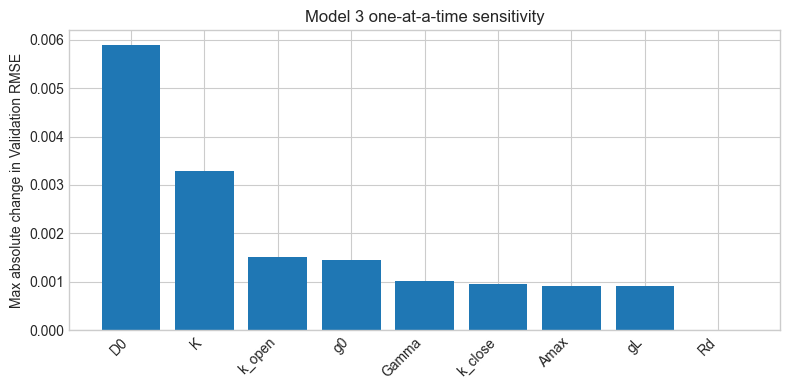

Most influential parameter in this local sensitivity analysis: D0 (max |Delta RMSE| = 0.00589)


In [17]:
def get_presentation_model3_parameter_array():
    if "model_3_params" in globals():
        return model_3_params_to_array(model_3_params)
    if "fitted_params" in globals() and isinstance(fitted_params, dict) and "Model 3" in fitted_params:
        params = fitted_params["Model 3"]
        if isinstance(params, dict):
            return np.asarray([params[name] for name in MODEL_3_SPEC["names"]], dtype=float)
        return np.asarray(params, dtype=float)
    params, result = fit_model_3_asymmetric_dynamic(train_df)
    globals()["model_3_params"] = params
    globals()["model_3_result"] = result
    return model_3_params_to_array(params)


def predict_presentation_model3(df, params):
    if "predict_model" in globals():
        try:
            return predict_model("Model 3", params, df)
        except Exception:
            pass
    return asymmetric_dynamic_leuning_model(df, params)


def model3_one_at_a_time_sensitivity(validation_df, perturb_fraction=0.10):
    base_params = get_presentation_model3_parameter_array()
    base_pred = predict_presentation_model3(validation_df, base_params)
    baseline_rmse = calculate_metrics(validation_df["gsw"], base_pred)["RMSE"]

    rows = []
    lower = np.asarray(MODEL_3_SPEC["lower"], dtype=float)
    upper = np.asarray(MODEL_3_SPEC["upper"], dtype=float)

    for i, parameter in enumerate(MODEL_3_SPEC["names"]):
        for direction, multiplier in [("+10%", 1 + perturb_fraction), ("-10%", 1 - perturb_fraction)]:
            perturbed = base_params.copy()
            perturbed[i] = np.clip(perturbed[i] * multiplier, lower[i], upper[i])
            y_pred = predict_presentation_model3(validation_df, perturbed)
            rmse = calculate_metrics(validation_df["gsw"], y_pred)["RMSE"]
            rows.append({
                "Parameter": parameter,
                "Perturbation": direction,
                "RMSE": rmse,
                "Delta_RMSE": rmse - baseline_rmse,
                "Abs_Delta_RMSE": abs(rmse - baseline_rmse),
            })

    sensitivity_table = pd.DataFrame(rows)
    sensitivity_magnitude = (
        sensitivity_table.groupby("Parameter", as_index=False)["Abs_Delta_RMSE"]
        .max()
        .sort_values("Abs_Delta_RMSE", ascending=False)
    )
    return baseline_rmse, sensitivity_table, sensitivity_magnitude


model3_baseline_validation_rmse, model3_sensitivity_table, model3_sensitivity_magnitude = model3_one_at_a_time_sensitivity(validation_df)

print(f"Baseline Model 3 Validation RMSE: {model3_baseline_validation_rmse:.4f}")
print()
print("Model 3 one-at-a-time sensitivity table")
display(model3_sensitivity_table[["Parameter", "Perturbation", "RMSE", "Delta_RMSE"]].round(5))

plt.figure(figsize=(8, 4))
plt.bar(model3_sensitivity_magnitude["Parameter"], model3_sensitivity_magnitude["Abs_Delta_RMSE"])
plt.ylabel("Max absolute change in Validation RMSE")
plt.title("Model 3 one-at-a-time sensitivity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_sensitive_parameter = model3_sensitivity_magnitude.iloc[0]["Parameter"]
top_sensitive_delta = model3_sensitivity_magnitude.iloc[0]["Abs_Delta_RMSE"]
print(f"Most influential parameter in this local sensitivity analysis: {top_sensitive_parameter} (max |Delta RMSE| = {top_sensitive_delta:.5f})")

## Uncertainty Analysis: Monte Carlo Parameter Uncertainty for Model 3

After using Model 3 as the main interpretable asymmetric dynamic model, Monte Carlo parameter uncertainty analysis was performed. Instead of relying on one fitted parameter set, multiple plausible parameter sets were sampled around the fitted Model 3 parameters. Model 3 was then rerun for each parameter sample to estimate how parameter uncertainty propagates into predicted stomatal conductance.

This analysis focuses only on the mechanistic Model 3, not on the LSTM or Ridge residual correction models, because Model 3 parameters have direct physiological interpretation.

Sensitivity analysis and uncertainty analysis answer different questions. Sensitivity analysis identifies which parameters most influence model performance by perturbing one parameter at a time. Uncertainty analysis estimates the range of predicted `gsw` caused by plausible simultaneous variation in all fitted parameters.

Model 3 Monte Carlo parameter uncertainty sampling
Sampling method: Independent 10% normal fallback
Attempted samples: 10000
Valid samples: 442
Acceptance rate: 4.4%

First five valid parameter samples


,Amax,K,Rd,g0,gL,Gamma,D0,k_open,k_close
0,33.68188,1064.58190,0.0,0.08465,47.38982,83.55470,0.13991,0.00437,0.00694
1,31.87755,1135.16340,0.0,0.08835,47.94623,83.16186,0.13825,0.00425,0.00772
2,34.81224,1039.02959,0.0,0.08564,47.44558,88.98633,0.14100,0.00486,0.00651
3,30.56028,1009.59485,0.0,0.09920,47.36729,92.42085,0.14782,0.00472,0.00746
4,34.42633,964.23306,0.0,0.09055,48.49736,96.70479,0.13556,0.00454,0.00738



Model 3 Monte Carlo validation metric summary


,Metric,Baseline Model 3,Mean,Median,2.5%,97.5%
0,Validation RMSE,0.0686,0.0766,0.0735,0.0673,0.0998
1,Validation R2,0.6236,0.5241,0.5681,0.2042,0.6378
2,Validation Bias,0.0122,-0.0242,-0.0251,-0.0681,0.0271


Representative file for Model 3 validation uncertainty from Monte Carlo parameter sampling: 2023-09-04-1143_logdata_silvere3_flash (baseline RMSE = 0.0724)


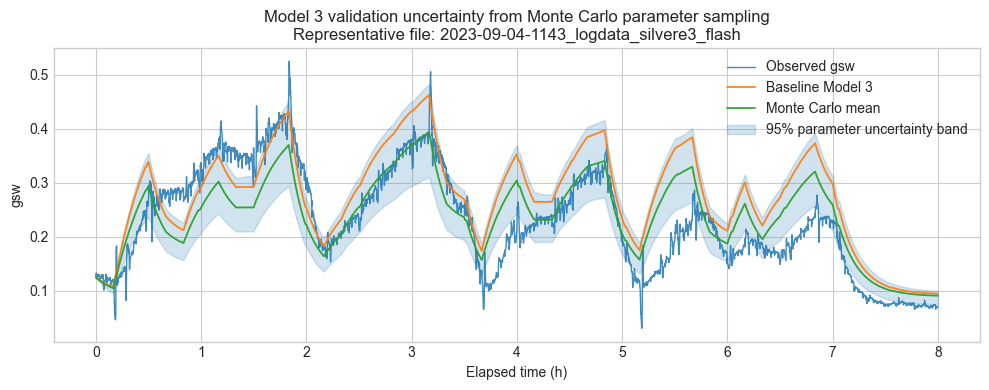

Representative file for Model 3 training uncertainty from Monte Carlo parameter sampling: 2023-10-24-1257_logdata_silvere2_flash (baseline RMSE = 0.0416)


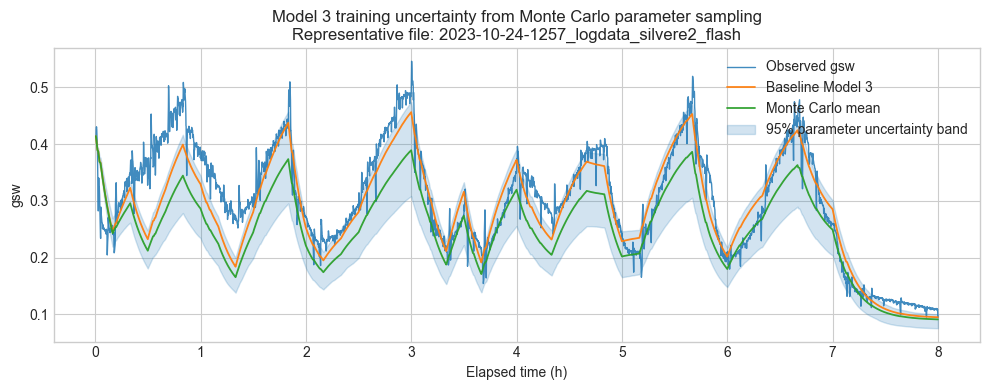

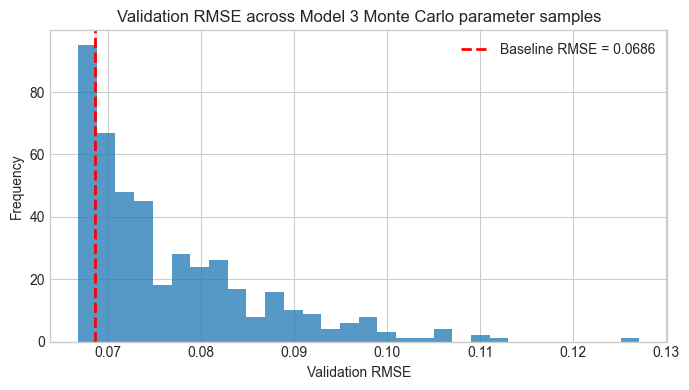

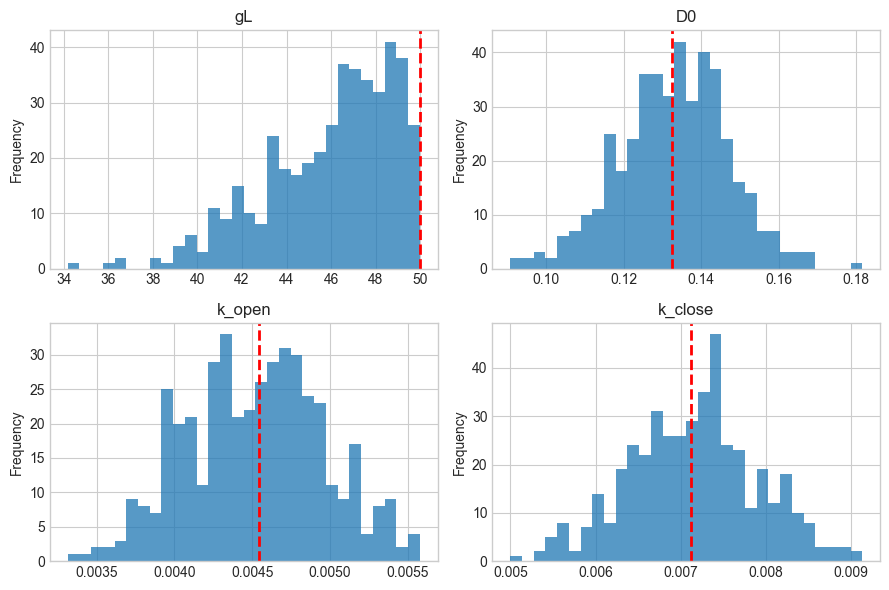


### Monte Carlo Parameter Uncertainty Interpretation

- Valid Monte Carlo parameter samples used: `442`.
- Baseline Model 3 Validation RMSE: `0.0686`.
- Monte Carlo Validation RMSE 95% range: `0.0673` to `0.0998`.
- Training coverage inside the 95% parameter uncertainty band: `56.7%`.
- Validation coverage inside the 95% parameter uncertainty band: `45.7%`.
- Mean Training band width: `0.0979` gsw.
- Mean Validation band width: `0.0986` gsw.

This suggests that parameter uncertainty alone cannot explain all prediction errors. Remaining mismatch may come from model structural limitations, leaf-to-leaf variation, measurement noise, or unmodelled physiological processes. The uncertainty band was wider during transition periods than during more stable periods. Uncertainty was larger around higher predicted gsw peaks. The average uncertainty band was wider for Validation than Training.

This Monte Carlo band represents only parameter uncertainty under the chosen Model 3 structure. It does not fully capture measurement error, structural model error, leaf-to-leaf variation, plant-to-plant variation, unmodelled photosynthetic induction dynamics, or residual model uncertainty.


In [18]:
from IPython.display import Markdown


def get_model3_uncertainty_state():
    """Return Model 3 parameter names, fitted array, fitting result, and bounds."""
    model3_param_names = list(MODEL_3_SPEC["names"])
    lower = np.asarray(MODEL_3_SPEC["lower"], dtype=float)
    upper = np.asarray(MODEL_3_SPEC["upper"], dtype=float)

    if "model_3_params" in globals():
        baseline_params = model_3_params_to_array(model_3_params)
        result = globals().get("model_3_result", None)
    elif "fitted_params" in globals() and isinstance(fitted_params, dict) and "Model 3" in fitted_params:
        params = fitted_params["Model 3"]
        if isinstance(params, dict):
            baseline_params = np.asarray([params[name] for name in model3_param_names], dtype=float)
        else:
            baseline_params = np.asarray(params, dtype=float)
        result = globals().get("model_3_result", None)
    else:
        params, result = fit_model_3_asymmetric_dynamic(train_df)
        globals()["model_3_params"] = params
        globals()["model_3_result"] = result
        baseline_params = model_3_params_to_array(params)

    if result is None:
        _, result = fit_model_3_asymmetric_dynamic(train_df)
        globals()["model_3_result"] = result

    return model3_param_names, baseline_params, result, lower, upper


def stabilize_covariance_matrix(cov, min_eigenvalue=1e-12):
    """Make a covariance matrix symmetric and positive semi-definite for sampling."""
    cov = np.asarray(cov, dtype=float)
    cov = (cov + cov.T) / 2
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = np.clip(eigenvalues, min_eigenvalue, None)
    return eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T


def approximate_model3_covariance(result, n_params):
    """Approximate parameter covariance from the least-squares Jacobian."""
    if result is None or not hasattr(result, "jac") or result.jac is None:
        return None

    J = np.asarray(result.jac, dtype=float)
    if J.ndim != 2 or J.shape[1] != n_params:
        return None

    n_obs = J.shape[0]
    dof = max(n_obs - n_params, 1)
    sigma2 = 2 * result.cost / dof
    jt_j = J.T @ J
    cov = sigma2 * np.linalg.pinv(jt_j)

    if not np.all(np.isfinite(cov)):
        return None

    return stabilize_covariance_matrix(cov)


def valid_model3_sample_mask(samples, lower, upper):
    samples = np.asarray(samples, dtype=float)
    finite = np.all(np.isfinite(samples), axis=1)
    within_bounds = np.all((samples >= lower) & (samples <= upper), axis=1)

    names = MODEL_3_SPEC["names"]
    positive_required = ["Amax", "K", "D0", "k_open", "k_close"]
    positive_mask = np.ones(samples.shape[0], dtype=bool)
    for name in positive_required:
        idx = names.index(name)
        positive_mask &= samples[:, idx] > 0

    return finite & within_bounds & positive_mask


def collect_valid_model3_samples(
    baseline_params,
    lower,
    upper,
    target_valid=1000,
    minimum_valid=200,
    max_attempts=10000,
    covariance=None,
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)
    n_params = len(baseline_params)

    def collect_from_sampler(method_name, sampler):
        valid_batches = []
        attempts = 0
        batch_size = min(1000, max_attempts)

        while attempts < max_attempts and sum(len(batch) for batch in valid_batches) < target_valid:
            current_batch = min(batch_size, max_attempts - attempts)
            sampled = sampler(current_batch)
            attempts += current_batch
            mask = valid_model3_sample_mask(sampled, lower, upper)
            if np.any(mask):
                valid_batches.append(sampled[mask])

        if valid_batches:
            valid = np.vstack(valid_batches)[:target_valid]
        else:
            valid = np.empty((0, n_params))

        return method_name, valid, attempts

    if covariance is not None:
        method, valid, attempts = collect_from_sampler(
            "Jacobian covariance multivariate normal",
            lambda size: rng.multivariate_normal(baseline_params, covariance, size=size, check_valid="ignore"),
        )
        if len(valid) >= minimum_valid:
            return method, valid, attempts

    fallback_sd = np.maximum(0.10 * np.abs(baseline_params), 1e-6)
    method, valid, attempts = collect_from_sampler(
        "Independent 10% normal fallback",
        lambda size: rng.normal(loc=baseline_params, scale=fallback_sd, size=(size, n_params)),
    )
    return method, valid, attempts


def predict_model3_uncertainty(df, params):
    return predict_presentation_model3(df, np.asarray(params, dtype=float))


def run_model3_monte_carlo_predictions(df, samples):
    predictions = []
    for params in samples:
        predictions.append(predict_model3_uncertainty(df, params))
    return np.asarray(predictions, dtype=float)


def add_mc_prediction_columns(df, prefix, baseline_pred, mc_predictions):
    df[f"{prefix}_baseline"] = baseline_pred
    df[f"{prefix}_mc_mean"] = np.nanmean(mc_predictions, axis=0)
    df[f"{prefix}_mc_median"] = np.nanmedian(mc_predictions, axis=0)
    df[f"{prefix}_mc_lower95"] = np.nanpercentile(mc_predictions, 2.5, axis=0)
    df[f"{prefix}_mc_upper95"] = np.nanpercentile(mc_predictions, 97.5, axis=0)


def mc_metric_summary(validation_df, validation_predictions_mc, baseline_validation_pred):
    rows = []
    for prediction in validation_predictions_mc:
        metrics = calculate_metrics(validation_df["gsw"], prediction)
        rows.append({
            "Validation RMSE": metrics["RMSE"],
            "Validation R2": metrics["R2"],
            "Validation Bias": metrics["Bias"],
        })

    metric_samples = pd.DataFrame(rows)
    summary_rows = []
    baseline_metrics = calculate_metrics(validation_df["gsw"], baseline_validation_pred)
    baseline_lookup = {
        "Validation RMSE": baseline_metrics["RMSE"],
        "Validation R2": baseline_metrics["R2"],
        "Validation Bias": baseline_metrics["Bias"],
    }

    for metric in ["Validation RMSE", "Validation R2", "Validation Bias"]:
        values = metric_samples[metric].to_numpy(dtype=float)
        summary_rows.append({
            "Metric": metric,
            "Baseline Model 3": baseline_lookup[metric],
            "Mean": np.nanmean(values),
            "Median": np.nanmedian(values),
            "2.5%": np.nanpercentile(values, 2.5),
            "97.5%": np.nanpercentile(values, 97.5),
        })

    return metric_samples, pd.DataFrame(summary_rows)


def uncertainty_x_axis(df):
    if "elapsed" in df.columns:
        x = pd.to_numeric(df["elapsed"], errors="coerce").to_numpy(dtype=float)
        if np.nanmax(x) > 100:
            x = x / 3600
        return x, "Elapsed time (h)"
    return np.arange(len(df)), "Row index"


def select_representative_uncertainty_file(df):
    """Choose a representative file with baseline RMSE closest to the per-file median RMSE."""
    if "_file" not in df.columns:
        return None, df.copy(), pd.DataFrame()

    rows = []
    for file_name, group in df.groupby("_file", sort=False):
        if group.empty:
            continue
        metrics = calculate_metrics(group["gsw"], group["gsw_model3_baseline"])
        rows.append({"_file": file_name, "RMSE": metrics["RMSE"], "n_rows": len(group)})

    file_metrics = pd.DataFrame(rows)
    if file_metrics.empty:
        return None, df.copy(), file_metrics

    median_rmse = file_metrics["RMSE"].median()
    file_metrics["distance_to_median_RMSE"] = (file_metrics["RMSE"] - median_rmse).abs()
    selected = file_metrics.sort_values(["distance_to_median_RMSE", "_file"]).iloc[0]
    selected_file = selected["_file"]
    selected_group = df[df["_file"] == selected_file].copy()
    return selected_file, selected_group, file_metrics


def plot_model3_uncertainty_timeseries(df, title):
    selected_file, plot_df, file_metrics = select_representative_uncertainty_file(df)
    if selected_file is not None:
        selected_rmse = file_metrics.loc[file_metrics["_file"] == selected_file, "RMSE"].iloc[0]
        print(f"Representative file for {title}: {selected_file} (baseline RMSE = {selected_rmse:.4f})")

    x, xlabel = uncertainty_x_axis(plot_df)
    x = np.asarray(x, dtype=float)
    observed = plot_df["gsw"].to_numpy(dtype=float)
    baseline = plot_df["gsw_model3_baseline"].to_numpy(dtype=float)
    mc_mean = plot_df["gsw_model3_mc_mean"].to_numpy(dtype=float)
    lower = plot_df["gsw_model3_mc_lower95"].to_numpy(dtype=float)
    upper = plot_df["gsw_model3_mc_upper95"].to_numpy(dtype=float)

    plt.figure(figsize=(10, 4))
    plt.plot(x, observed, color="tab:blue", linewidth=1.0, alpha=0.85, label="Observed gsw")
    plt.plot(x, baseline, color="tab:orange", linewidth=1.3, alpha=0.95, label="Baseline Model 3")
    plt.plot(x, mc_mean, color="tab:green", linewidth=1.3, alpha=0.95, label="Monte Carlo mean")
    plt.fill_between(x, lower, upper, color="tab:blue", alpha=0.20, label="95% parameter uncertainty band")
    plt.xlabel(xlabel)
    plt.ylabel("gsw")
    plot_title = title
    if selected_file is not None:
        plot_title += chr(10) + f"Representative file: {selected_file}"
    plt.title(plot_title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_uncertainty_coverage(df):
    inside = (df["gsw"] >= df["gsw_model3_mc_lower95"]) & (df["gsw"] <= df["gsw_model3_mc_upper95"])
    width = df["gsw_model3_mc_upper95"] - df["gsw_model3_mc_lower95"]
    return float(inside.mean()), float(width.mean())


def transition_uncertainty_summary(df):
    width = (df["gsw_model3_mc_upper95"] - df["gsw_model3_mc_lower95"]).to_numpy(dtype=float)
    baseline = df["gsw_model3_baseline"].to_numpy(dtype=float)
    changes = np.abs(np.diff(baseline, prepend=baseline[0]))
    peak_mask = baseline >= np.nanpercentile(baseline, 75)
    transition_mask = changes >= np.nanpercentile(changes, 75)
    peak_width = np.nanmean(width[peak_mask])
    non_peak_width = np.nanmean(width[~peak_mask])
    transition_width = np.nanmean(width[transition_mask])
    stable_width = np.nanmean(width[~transition_mask])
    return peak_width, non_peak_width, transition_width, stable_width


model3_param_names, model3_baseline_params, model3_uncertainty_result, model3_lower, model3_upper = get_model3_uncertainty_state()
model3_covariance = approximate_model3_covariance(model3_uncertainty_result, len(model3_baseline_params))

mc_sampling_method, model3_parameter_samples, mc_attempts = collect_valid_model3_samples(
    model3_baseline_params,
    model3_lower,
    model3_upper,
    target_valid=1000,
    minimum_valid=200,
    max_attempts=10000,
    covariance=model3_covariance,
    random_seed=42,
)

valid_mc_samples = len(model3_parameter_samples)
acceptance_rate = valid_mc_samples / mc_attempts if mc_attempts else np.nan

print("Model 3 Monte Carlo parameter uncertainty sampling")
print(f"Sampling method: {mc_sampling_method}")
print(f"Attempted samples: {mc_attempts}")
print(f"Valid samples: {valid_mc_samples}")
print(f"Acceptance rate: {acceptance_rate:.1%}")

if valid_mc_samples < 200:
    raise RuntimeError("Fewer than 200 valid Model 3 parameter samples were generated. Check parameter bounds or sampling scale.")

model3_parameter_sample_table = pd.DataFrame(model3_parameter_samples, columns=model3_param_names)
print("\nFirst five valid parameter samples")
display(model3_parameter_sample_table.head().round(5))

baseline_train_pred = predict_model3_uncertainty(train_df, model3_baseline_params)
baseline_validation_pred = predict_model3_uncertainty(validation_df, model3_baseline_params)

train_predictions_mc = run_model3_monte_carlo_predictions(train_df, model3_parameter_samples)
validation_predictions_mc = run_model3_monte_carlo_predictions(validation_df, model3_parameter_samples)

add_mc_prediction_columns(train_df, "gsw_model3", baseline_train_pred, train_predictions_mc)
add_mc_prediction_columns(validation_df, "gsw_model3", baseline_validation_pred, validation_predictions_mc)

model3_mc_metric_samples, model3_mc_metric_summary = mc_metric_summary(
    validation_df,
    validation_predictions_mc,
    baseline_validation_pred,
)

print("\nModel 3 Monte Carlo validation metric summary")
display(model3_mc_metric_summary.round(4))

plot_model3_uncertainty_timeseries(
    validation_df,
    "Model 3 validation uncertainty from Monte Carlo parameter sampling",
)

plot_model3_uncertainty_timeseries(
    train_df,
    "Model 3 training uncertainty from Monte Carlo parameter sampling",
)

baseline_validation_rmse = calculate_metrics(validation_df["gsw"], baseline_validation_pred)["RMSE"]
plt.figure(figsize=(7, 4))
plt.hist(model3_mc_metric_samples["Validation RMSE"], bins=30, alpha=0.75)
plt.axvline(baseline_validation_rmse, color="red", linestyle="--", linewidth=2, label=f"Baseline RMSE = {baseline_validation_rmse:.4f}")
plt.xlabel("Validation RMSE")
plt.ylabel("Frequency")
plt.title("Validation RMSE across Model 3 Monte Carlo parameter samples")
plt.legend()
plt.tight_layout()
plt.show()

key_parameters = ["gL", "D0", "k_open", "k_close"]
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, parameter in zip(axes.ravel(), key_parameters):
    ax.hist(model3_parameter_sample_table[parameter], bins=30, alpha=0.75)
    ax.axvline(model3_baseline_params[model3_param_names.index(parameter)], color="red", linestyle="--", linewidth=2)
    ax.set_title(parameter)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

train_coverage, train_mean_band_width = summarize_uncertainty_coverage(train_df)
validation_coverage, validation_mean_band_width = summarize_uncertainty_coverage(validation_df)
peak_width, non_peak_width, transition_width, stable_width = transition_uncertainty_summary(validation_df)

rmse_low = model3_mc_metric_summary.loc[model3_mc_metric_summary["Metric"] == "Validation RMSE", "2.5%"].iloc[0]
rmse_high = model3_mc_metric_summary.loc[model3_mc_metric_summary["Metric"] == "Validation RMSE", "97.5%"].iloc[0]

if validation_coverage >= 0.80:
    coverage_sentence = "The uncertainty band captured much of the observed validation variation, suggesting that parameter uncertainty explains part of the prediction mismatch."
else:
    coverage_sentence = "This suggests that parameter uncertainty alone cannot explain all prediction errors. Remaining mismatch may come from model structural limitations, leaf-to-leaf variation, measurement noise, or unmodelled physiological processes."

if transition_width > stable_width:
    transition_sentence = "The uncertainty band was wider during transition periods than during more stable periods."
else:
    transition_sentence = "The uncertainty band was not clearly wider during transition periods than during more stable periods."

if peak_width > non_peak_width:
    peak_sentence = "Uncertainty was larger around higher predicted gsw peaks."
else:
    peak_sentence = "Uncertainty was not clearly larger around higher predicted gsw peaks."

if validation_mean_band_width > train_mean_band_width:
    dataset_sentence = "The average uncertainty band was wider for Validation than Training."
else:
    dataset_sentence = "The average uncertainty band was similar or narrower for Validation than Training."

uncertainty_interpretation = f"""
### Monte Carlo Parameter Uncertainty Interpretation

- Valid Monte Carlo parameter samples used: `{valid_mc_samples}`.
- Baseline Model 3 Validation RMSE: `{baseline_validation_rmse:.4f}`.
- Monte Carlo Validation RMSE 95% range: `{rmse_low:.4f}` to `{rmse_high:.4f}`.
- Training coverage inside the 95% parameter uncertainty band: `{train_coverage:.1%}`.
- Validation coverage inside the 95% parameter uncertainty band: `{validation_coverage:.1%}`.
- Mean Training band width: `{train_mean_band_width:.4f}` gsw.
- Mean Validation band width: `{validation_mean_band_width:.4f}` gsw.

{coverage_sentence} {transition_sentence} {peak_sentence} {dataset_sentence}

This Monte Carlo band represents only parameter uncertainty under the chosen Model 3 structure. It does not fully capture measurement error, structural model error, leaf-to-leaf variation, plant-to-plant variation, unmodelled photosynthetic induction dynamics, or residual model uncertainty.
"""

display(Markdown(uncertainty_interpretation))

### Presentation-Ready Uncertainty Summary

Monte Carlo uncertainty analysis improved the interpretation of Model 3 by showing the expected prediction range caused by parameter uncertainty. This does not reduce RMSE directly, but it helps determine whether validation mismatch is likely due to parameter uncertainty or to structural limitations such as leaf-to-leaf variation.

This uncertainty analysis should be interpreted as a parameter uncertainty analysis for the mechanistic Model 3 only. It is not an uncertainty analysis for the LSTM or Ridge residual corrections.

## Interpretation of Results

Model 0 captured only a rough average response and missed dynamic peaks under fluctuating light. Model 1 improved only slightly because a static Leuning-style model was still insufficient for the fluctuating light response. Model 2 improved performance substantially by adding dynamic lag, which allowed predicted `gsw` to respond gradually rather than instantaneously. Model 3 added separate opening and closing response rates, making it a useful physiological extension, but in the current one-stage results it did not clearly outperform Model 2 on Validation metrics.

Validation was not perfectly aligned with observations, likely because of leaf-to-leaf variation, day-to-day differences, file-specific behaviour, and simplifications in the photosynthesis sub-model. R2 alone cannot fully describe model quality, so RMSE, bias, time-series shape, validation plots, and biological interpretability should all be considered together.

## Residual Model Interpretation

The LSTM residual correction learned Training residuals very strongly, which produced a large Training improvement but also raised overfitting risk because the dataset contains many rows but only a limited number of independent time-series files. The Ridge residual correction is simpler and more regularized. It was used to test whether systematic scaling bias could be corrected with less overfitting risk. Residual models should be treated as exploratory extensions, not the main final mechanistic model, unless their validation improvement is consistent across independent files.

## Conclusions

- Model 2 had the best Validation RMSE and R2 among the current one-stage Model 0-3 comparison.
- Dynamic stomatal response improved prediction under fluctuating light.
- Model 3 is still biologically useful because it tests asymmetric opening and closing rates.
- Leaf-to-leaf variation and day/file differences limited perfect alignment between prediction and validation observations.
- Future work should include more independent leaves, plant-level scaling, dynamic photosynthesis induction, and carefully validated residual hybrid models.

## Slide Plan for a 10-Minute Presentation

| Slide | Title | Key points | Figure/table to use | Speaker notes |
|---:|---|---|---|---|
| 1 | Title | Research question; predicting stomatal conductance under fluctuating light | Title slide with model schematic | State the biological problem and modelling goal clearly. |
| 2 | Introduction & Context | `gsw` controls CO2 uptake and water loss; photosynthesis-transpiration trade-off | Simple stomata / gas exchange diagram | Explain why stomatal conductance matters for plant performance. |
| 3 | Dataset Description | LI-COR 6800 data; 6 Training files; 5 Validation files; target and predictors | Dataset summary table | Mention that measured `A` is not used directly for `gsw` prediction. |
| 4 | Conceptual / Forrester Diagram | Inputs, photosynthesis sub-model, stomatal model, dynamic state, output | Forrester / conceptual model diagram | Use this slide to orient the audience before equations. |
| 5 | Model Progression | Model 0 to Model 3; increasing physiological structure and dynamics | Model progression flowchart | Explain why each model was added. |
| 6 | Model Equations | `A_model`; Leuning target; dynamic lag; asymmetric lag | Equation slide | Keep equations short and explain terms verbally. |
| 7 | One-Stage Parameter Fitting | Training `gsw` used to fit model parameters; Validation kept separate | Parameter fitting workflow diagram | Emphasize that fitted parameters are fixed during validation simulation. |
| 8 | Model Comparison | RMSE, R2, Bias for Models 0-3 | Clean comparison table and validation RMSE bar plot | Highlight Model 2 as best validation model and Model 3 as the asymmetric extension. |
| 9 | Model 3 Time-Series | Dynamic prediction; validation shape; remaining mismatch | Model 3 validation time-series | Discuss peaks, lags, and leaf/file variation. |
| 10 | Sensitivity Analysis | Parameters perturbed +/-10%; validation RMSE response | Model 3 sensitivity bar plot | Identify which parameters most influence prediction. |
| 11 | Residual Models / Future Extension | LSTM overfitting risk; Ridge as simpler correction | LSTM/Ridge validation comparison plot | Present residual models as exploratory extensions. |
| 12 | Conclusions | Main findings; limitations; future work | Final conclusion bullets | End with Model 2 validation performance, Model 3 interpretation, and future improvements. |

## Figure Recommendations for the Final Presentation

Recommended figures and tables to keep:

- Forrester / conceptual model diagram showing environmental inputs, photosynthesis sub-model, stomatal model, dynamic state, and predicted `gsw`.
- One-stage parameter fitting workflow diagram.
- Clean Model 0-3 model comparison table.
- Model 0 Validation time-series as a simple baseline.
- Model 2 and Model 3 Validation time-series to compare best validation performance with asymmetric dynamics.
- Model 3 sensitivity analysis bar plot.
- LSTM residual Training vs Validation plot as an exploratory overfitting example.
- Optional: Ridge residual Validation plot if presenting hybrid models as future predictive extensions.